# The Evolution of LeBron James: A 21-Year Shooting Analysis

31,182 shots · 1,594 games · 23 seasons · One player.

This notebook walks through the full shot-by-shot analysis of LeBron James's regular season career from 2003-04 through the present. All data comes from a DuckDB database built with dbt. Each section queries the mart tables directly and renders charts inline.

Sections
1. Setup
2. Career Overview
3. The Era Divide - Dead-Ball vs Three-Point
4. The Four Chapters - Team Tenures
5. Clutch Gene
6. Opponent Analysis
7. Shot Selection Evolution
8. Career Trajectory
9. The Best Season
10. Summary


## 1. Setup

In [5]:
import duckdb
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Arc, Rectangle, Circle
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

%matplotlib inline
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.25,
    'grid.linestyle':     '--',
    'figure.dpi':         130,
    'savefig.dpi':        130,
    'savefig.bbox':       'tight',
    'savefig.facecolor':  'white',
})

# ── Palette ───────────────────────────────────────────────────────────────────
PURPLE       = '#552583'
GOLD         = '#FDB927'
CAVS_WINE    = '#6F263D'
CAVS_GOLD    = '#FFB81C'
HEAT_RED     = '#98002E'
ERA_DEAD     = '#1A6B9A'
ERA_THREE    = '#552583'
CLUTCH_RED   = '#C0392B'
REGULAR_BLUE = '#2980B9'

TEAM_COLORS = {
    'Cavs I':  (CAVS_WINE,  CAVS_GOLD),
    'Heat':    (HEAT_RED,   '#F9A01B'),
    'Cavs II': (CAVS_WINE,  CAVS_GOLD),
    'Lakers':  (PURPLE,     GOLD),
}

# -----------------------DB connection--------------------------------
DB = "../lebron_analytics.duckdb"
conn = duckdb.connect(str(DB), read_only=True)
print(f"Connected: {DB}")

Connected: ../lebron_analytics.duckdb


## 2. Career Overview

Across 1,594 regular season games and 23 seasons, LeBron attempted 31,182 shots and made 15,786 - a 50.6% clip. Those makes generated 34,178 points from the field alone.

The NBA average FG% sits around 46-47%. LeBron has shot 3-4 points above that his entire career, while handling a massive usage rate and still playing heavy minutes at 39.

The 11.7-foot average shot distance is the detail that doesn't get enough attention. That's deep mid-range - not a rim-runner's number, not a perimeter specialist's. It's a player who has spent two decades operating in the contested middle of the court.


In [ ]:
career = conn.execute("""
    SELECT
        COUNT(*)                                         AS total_shots,
        SUM(is_shot_made::int)                          AS field_goals_made,
        ROUND(AVG(is_shot_made::int) * 100, 1)         AS fg_pct,
        SUM(points_scored)                               AS fg_points,
        COUNT(DISTINCT game_id)                          AS games,
        COUNT(DISTINCT season)                           AS seasons,
        ROUND(AVG(shot_distance), 1)                    AS avg_shot_distance
    FROM main.int_shots_enriched
""").df()

career.T.rename(columns={0: 'Value'}).style.set_caption('Career Totals')

,Value
total_shots,31182.000000
field_goals_made,15786.000000
fg_pct,50.600000
fg_points,34178.000000
games,1594.000000
seasons,23.000000
avg_shot_distance,11.700000


In [ ]:
# Season-by-season summary table
season_summary = conn.execute("""
    SELECT season, tenure, era,
           COUNT(*) AS shots,
           SUM(is_shot_made::int)                         AS made,
           ROUND(AVG(is_shot_made::int) * 100, 1)        AS fg_pct,
           ROUND(AVG(is_shot_made::int)
               FILTER (WHERE shot_type = '2PT Field Goal') * 100, 1) AS fg2_pct,
           ROUND(AVG(is_shot_made::int)
               FILTER (WHERE shot_type = '3PT Field Goal') * 100, 1) AS fg3_pct,
           ROUND(COUNT(*) FILTER (WHERE shot_type = '3PT Field Goal')
               ::decimal / COUNT(*) * 100, 1)             AS three_pt_rate,
           SUM(points_scored)                              AS fg_points,
           ROUND(SUM(points_scored)::decimal / COUNT(*), 3) AS pts_per_shot,
           ROUND(AVG(shot_distance), 1)                   AS avg_dist
    FROM main.int_shots_enriched
    WHERE tenure != 'Unknown'
    GROUP BY season, tenure, era
    ORDER BY season
""").df()

season_summary.style     .background_gradient(subset=['fg_pct'], cmap='RdYlGn', vmin=41, vmax=57)     .background_gradient(subset=['three_pt_rate'], cmap='Blues')     .format({'fg_pct': '{:.1f}%', 'fg2_pct': '{:.1f}%', 'fg3_pct': '{:.1f}%',
             'three_pt_rate': '{:.1f}%', 'pts_per_shot': '{:.3f}'})     .set_caption('Season-by-Season Summary')

,season,tenure,era,shots,made,fg_pct,fg2_pct,fg3_pct,three_pt_rate,fg_points,pts_per_shot,avg_dist
0,2003-04,Cavs I,Dead-ball Era,1492,622.000000,41.7%,43.8%,29.0%,14.5%,1307.000000,0.876,10.700000
1,2004-05,Cavs I,Dead-ball Era,1698,802.000000,47.2%,49.9%,35.1%,18.1%,1712.000000,1.008,11.600000
2,2005-06,Cavs I,Dead-ball Era,1837,882.000000,48.0%,51.8%,33.5%,20.6%,1891.000000,1.029,11.900000
3,2006-07,Cavs I,Dead-ball Era,1621,772.000000,47.6%,51.3%,31.9%,19.1%,1643.000000,1.014,11.700000
4,2007-08,Cavs I,Dead-ball Era,1642,794.000000,48.4%,53.1%,31.5%,21.9%,1701.000000,1.036,11.800000
5,2008-09,Cavs I,Dead-ball Era,1613,789.000000,48.9%,53.5%,34.4%,23.8%,1710.000000,1.060,13.000000
6,2009-10,Cavs I,Dead-ball Era,1556,775.000000,49.8%,55.3%,33.3%,24.9%,1679.000000,1.079,12.800000
7,2010-11,Heat,Dead-ball Era,1485,758.000000,51.0%,55.2%,33.0%,18.8%,1608.000000,1.083,12.300000
8,2011-12,Heat,Dead-ball Era,1169,621.000000,53.1%,55.6%,36.2%,12.7%,1296.000000,1.109,11.000000
9,2012-13,Heat,Dead-ball Era,1354,765.000000,56.5%,60.2%,40.6%,18.8%,1633.000000,1.206,10.800000


## 3. The Era Divide

The NBA's style transformation peaked around 2014-15 when the Warriors won the title and pace-and-space became the dominant framework. That season serves as the dividing line between two distinct phases of LeBron's career.

Dead-Ball Era (2003-2014): 80.2% of attempts were 2-pointers. Three-pointers were supplemental. His efficiency peaked in the final three Miami seasons: 53.1%, 56.5%, 56.7%.

Three-Point Era (2014-present): Three-point rate climbed from 22.6% to a career-high 36.7% in 2021-22. Overall FG% went *up* - 51.8% vs 49.6% - because the shots he traded away (long mid-range) were the worst-value attempts in his arsenal.

The key finding: taking more threes *improved* his scoring efficiency from 1.06 to 1.138 points per shot.


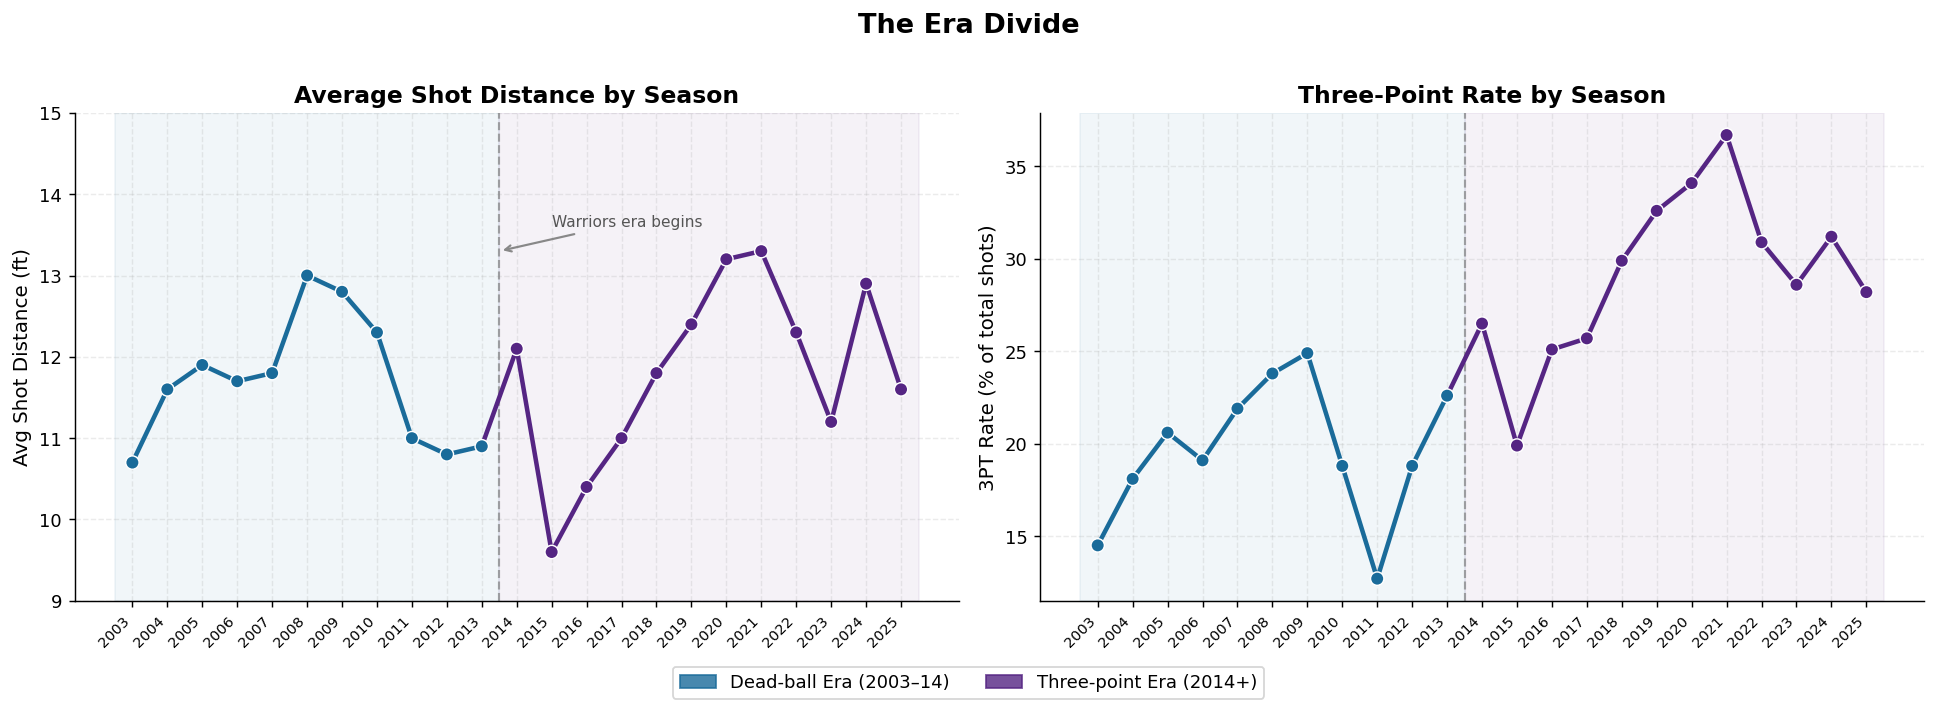

In [ ]:
era_season = conn.execute("""
    SELECT season, season_start_year, era, season_avg_shot_distance,
           season_fg_pct, season_three_pt_rate
    FROM main.mart_era_analysis
    GROUP BY season, season_start_year, era,
             season_avg_shot_distance, season_fg_pct, season_three_pt_rate
    ORDER BY season_start_year
""").fetchall()

seasons   = [r[0] for r in era_season]
years     = [r[1] for r in era_season]
eras      = [r[2] for r in era_season]
distances = [r[3] for r in era_season]
fg_pcts   = [r[4] for r in era_season]
three_rates = [r[5] for r in era_season]

clrs = [ERA_DEAD if e == 'Dead-ball Era' else ERA_THREE for e in eras]
x    = np.arange(len(seasons))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Shot distance trend ───────────────────────────────────────────────────────
ax = axes[0]
ax.axvspan(-0.5, 10.5, alpha=0.06, color=ERA_DEAD)
ax.axvspan(10.5, len(seasons)-0.5, alpha=0.06, color=ERA_THREE)
ax.axvline(10.5, color='grey', lw=1.2, ls='--', alpha=0.7)
ax.annotate('Warriors era begins', xy=(10.5, 13.3), xytext=(12, 13.6),
            fontsize=8.5, color='#555',
            arrowprops=dict(arrowstyle='->', color='#888', lw=1.2))
for i in range(len(x) - 1):
    ax.plot(x[i:i+2], distances[i:i+2], color=clrs[i+1], lw=2.5)
ax.scatter(x, distances, c=clrs, zorder=5, s=55, edgecolors='white', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([s[:4] for s in seasons], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Avg Shot Distance (ft)', fontsize=11)
ax.set_title("Average Shot Distance by Season", fontsize=13, fontweight='bold')
ax.set_ylim(9, 15)

# ── 3PT rate trend ────────────────────────────────────────────────────────────
ax = axes[1]
ax.axvspan(-0.5, 10.5, alpha=0.06, color=ERA_DEAD)
ax.axvspan(10.5, len(seasons)-0.5, alpha=0.06, color=ERA_THREE)
ax.axvline(10.5, color='grey', lw=1.2, ls='--', alpha=0.7)
for i in range(len(x) - 1):
    ax.plot(x[i:i+2], three_rates[i:i+2], color=clrs[i+1], lw=2.5)
ax.scatter(x, three_rates, c=clrs, zorder=5, s=55, edgecolors='white', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([s[:4] for s in seasons], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('3PT Rate (% of total shots)', fontsize=11)
ax.set_title("Three-Point Rate by Season", fontsize=13, fontweight='bold')

dead_p  = mpatches.Patch(color=ERA_DEAD,  alpha=0.8, label='Dead-ball Era (2003-14)')
three_p = mpatches.Patch(color=ERA_THREE, alpha=0.8, label='Three-point Era (2014+)')
fig.legend(handles=[dead_p, three_p], loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.06))
plt.suptitle("The Era Divide", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Era-level summary comparison
era_summary = conn.execute("""
    SELECT era,
           total_shots, total_seasons,
           overall_fg_pct       AS fg_pct,
           fg2_pct, fg3_pct,
           pct_shots_that_are_2pt AS two_pt_rate,
           pct_shots_that_are_3pt AS three_pt_rate,
           avg_shot_distance,
           points_per_shot
    FROM main.mart_era_analysis
    GROUP BY era, total_shots, total_seasons, overall_fg_pct,
             fg2_pct, fg3_pct, pct_shots_that_are_2pt,
             pct_shots_that_are_3pt, avg_shot_distance, points_per_shot
    ORDER BY era
""").df()

era_summary.style     .background_gradient(subset=['fg_pct'], cmap='RdYlGn', vmin=48, vmax=53)     .format({c: '{:.1f}%' for c in ['fg_pct','fg2_pct','fg3_pct',
                                      'two_pt_rate','three_pt_rate']})     .format({'avg_shot_distance': '{:.1f} ft', 'points_per_shot': '{:.3f}'})     .set_caption('Era Comparison')

,era,total_shots,total_seasons,fg_pct,fg2_pct,fg3_pct,two_pt_rate,three_pt_rate,avg_shot_distance,points_per_shot
0,Dead-ball Era,16820,11,49.600000,53.500000,34.100000,80.200000,19.800000,11.7 ft,1.060
1,Three-point Era,14362,12,51.800000,58.400000,35.600000,71.200000,28.800000,11.7 ft,1.138


## 4. The Four Chapters

LeBron's career splits cleanly into four team tenures, each with its own context, supporting cast, and shooting profile.

| Chapter | Team | Seasons | Story |
|---------|------|---------|-------|
| Cavs I | Cleveland | 2003-2010 | Building years - all volume, developing efficiency |
| Heat | Miami | 2010-2014 | Peak efficiency; system designed around his strengths |
| Cavs II | Cleveland | 2014-2018 | Return with more threes; 2016 championship |
| Lakers | Los Angeles | 2018-present | Highest 3PT rate; 2-point efficiency still elite |

The Heat years (54.3% FG) are his most efficient chapter by a significant margin. The system Spoelstra ran - LeBron attacking the paint, kick-outs for Bosh and Wade - gave him the highest proportion of shots in his best zones. Threes were for the role players; LeBron got layups and short mid-range pull-ups at 58%+.

The Cavs II and Lakers years show what happens when the three-point attempt rate climbs but the 2-point efficiency stays high. He's not substituting threes for paint production - he's adding them.


C:\Users\Ashim\AppData\Local\Temp\ipykernel_31976\2171386103.py:73: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


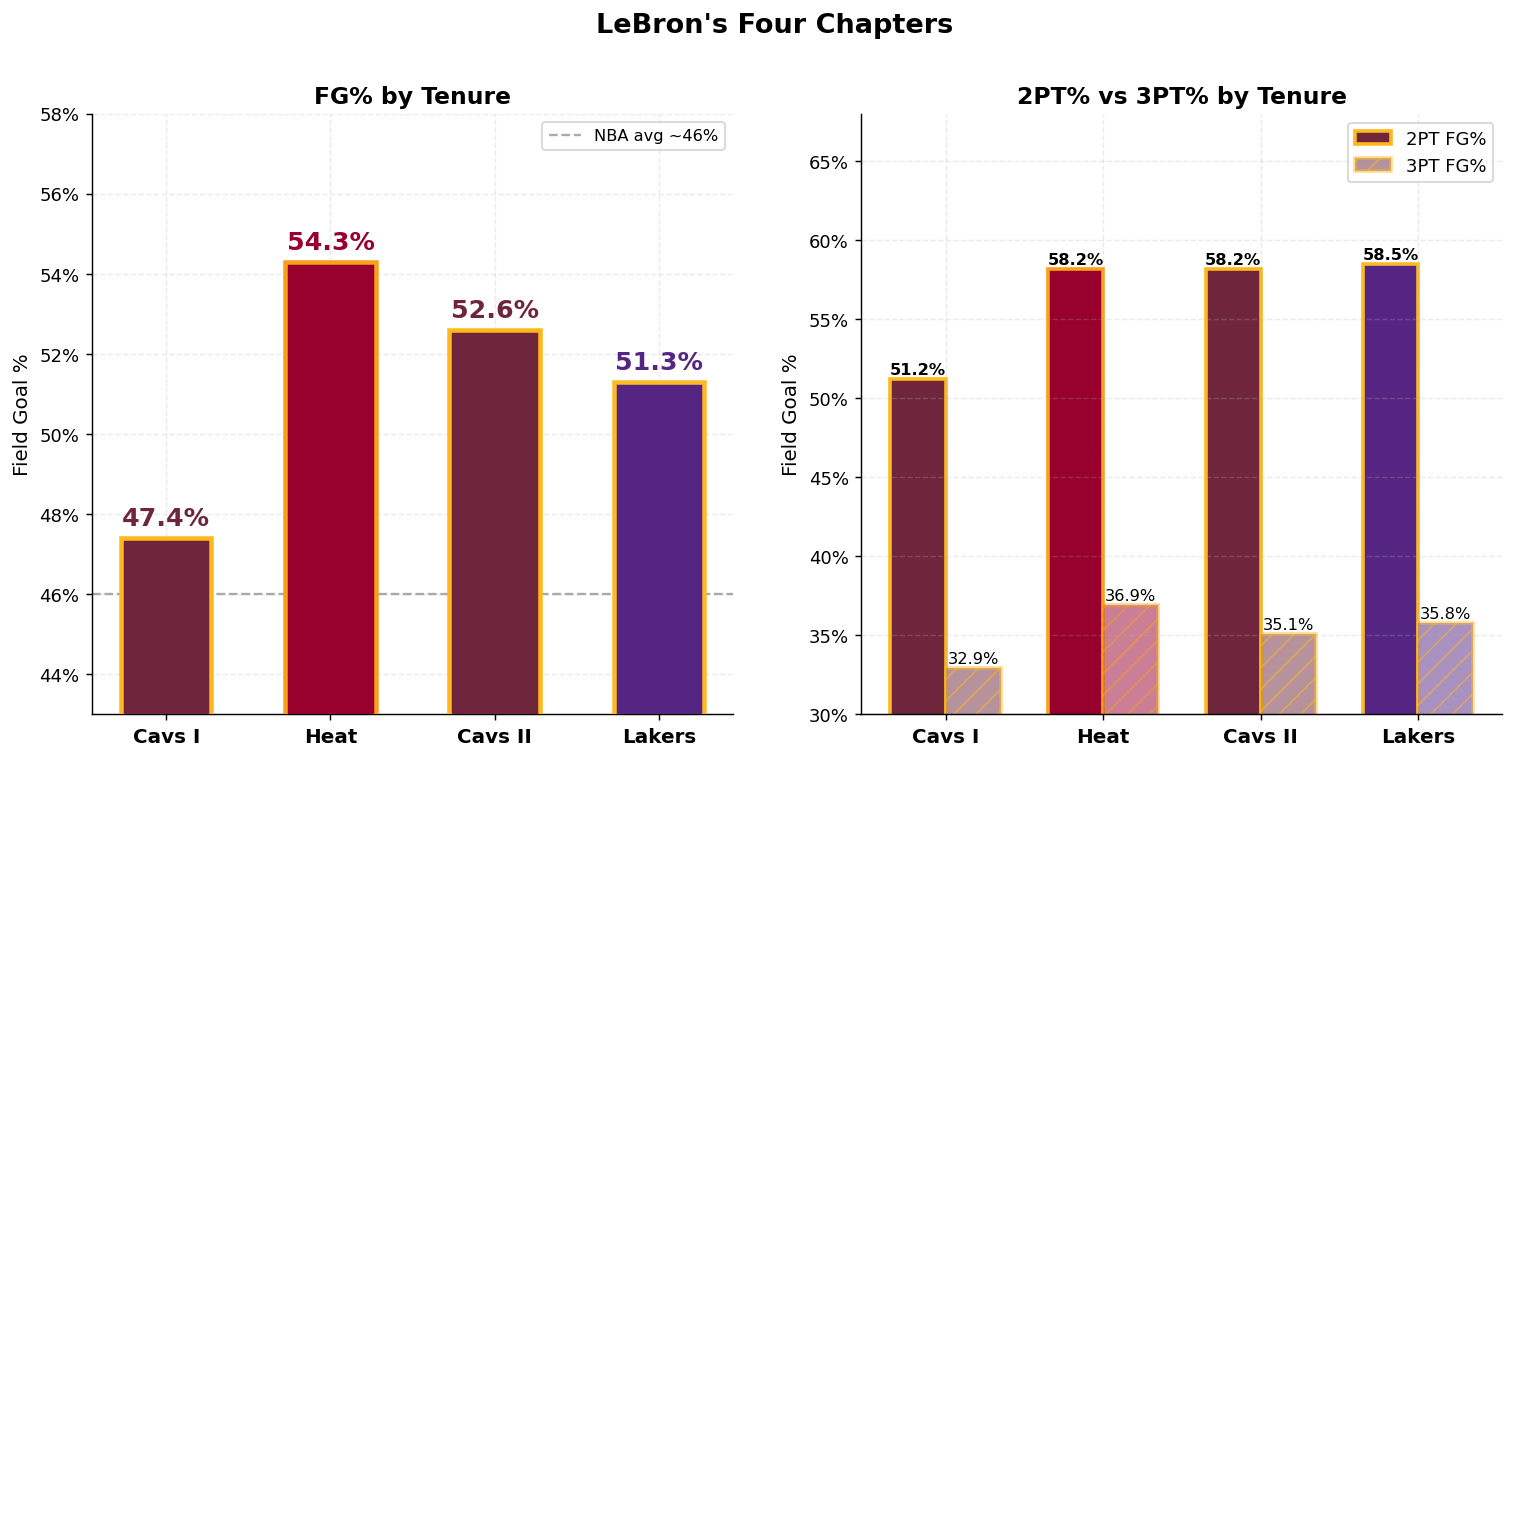

In [ ]:
tenure_data = conn.execute("""
    SELECT tenure, tenure_order,
           MIN(first_season) AS first_s, MAX(last_season) AS last_s,
           SUM(total_shots)  AS shots, SUM(total_games)   AS games,
           ROUND(SUM(total_made)*100.0/SUM(total_shots), 1) AS fg_pct,
           ROUND(SUM(made_2pt)*100.0/SUM(shots_2pt), 1)    AS fg2_pct,
           ROUND(SUM(made_3pt)*100.0/SUM(shots_3pt), 1)    AS fg3_pct,
           ROUND(SUM(shots_3pt)*100.0/SUM(total_shots), 1) AS three_rate,
           ROUND(SUM(total_points)::decimal/SUM(total_shots), 3) AS pps
    FROM (
        SELECT tenure, tenure_order, first_season, last_season,
               total_shots, total_games, total_made,
               shots_2pt, made_2pt, shots_3pt, made_3pt, total_points
        FROM main.mart_tenure_performance
        GROUP BY tenure, tenure_order, first_season, last_season,
                 total_shots, total_games, total_made,
                 shots_2pt, made_2pt, shots_3pt, made_3pt, total_points
    )
    GROUP BY tenure, tenure_order ORDER BY tenure_order
""").fetchall()

tenures    = [r[0] for r in tenure_data]
fg_pcts    = [r[6] for r in tenure_data]
fg2_pcts   = [r[7] for r in tenure_data]
fg3_pcts   = [r[8] for r in tenure_data]
three_rates = [r[9] for r in tenure_data]
shot_cnts  = [r[4] for r in tenure_data]
seasons    = [f"{r[2][:4]}-{r[3][:4]}" for r in tenure_data]
face_clrs  = [TEAM_COLORS[t][0] for t in tenures]
edge_clrs  = [TEAM_COLORS[t][1] for t in tenures]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── FG% bar ───────────────────────────────────────────────────────────────────
x = np.arange(len(tenures))
axes[0].axhline(46.0, color='#888', lw=1.3, ls='--', alpha=0.7, label='NBA avg ~46%')
bars = axes[0].bar(x, fg_pcts, color=face_clrs, edgecolor=edge_clrs,
                   linewidth=2.5, width=0.55, zorder=3)
for bar, fg, shots, seas, t3 in zip(bars, fg_pcts, shot_cnts, seasons, three_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{fg}%', ha='center', va='bottom', fontsize=14, fontweight='bold',
                 color=bar.get_facecolor())
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                 f'{shots:,} shots\n{seas}\n3PT: {t3}%',
                 ha='center', va='center', fontsize=8.5, color='white',
                 fontweight='bold', multialignment='center')
axes[0].set_xticks(x)
axes[0].set_xticklabels(tenures, fontsize=11, fontweight='bold')
axes[0].set_ylabel('Field Goal %', fontsize=11)
axes[0].set_title("FG% by Tenure", fontsize=13, fontweight='bold')
axes[0].set_ylim(43, 58)
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))

# ── 2PT vs 3PT % grouped bar ─────────────────────────────────────────────────
w = 0.35
axes[1].bar(x - w/2, fg2_pcts, w, color=face_clrs, edgecolor=edge_clrs, lw=2,
            label='2PT FG%')
axes[1].bar(x + w/2, fg3_pcts, w, color=face_clrs, edgecolor=edge_clrs, lw=2,
            alpha=0.5, hatch='//', label='3PT FG%')
for xi, f2, f3 in zip(x, fg2_pcts, fg3_pcts):
    axes[1].text(xi - w/2, f2 + 0.3, f'{f2}%', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(xi + w/2, f3 + 0.3, f'{f3}%', ha='center', fontsize=9)
axes[1].set_xticks(x)
axes[1].set_xticklabels(tenures, fontsize=11, fontweight='bold')
axes[1].set_ylabel('Field Goal %', fontsize=11)
axes[1].set_title("2PT% vs 3PT% by Tenure", fontsize=13, fontweight='bold')
axes[1].set_ylim(30, 68)
axes[1].legend(fontsize=10)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))

plt.suptitle("LeBron's Four Chapters", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Tenure summary table
tenure_df = pd.DataFrame(tenure_data,
    columns=['tenure','order','first_s','last_s','shots','games',
             'fg_pct','fg2_pct','fg3_pct','three_rate','pps'])
tenure_df.drop(columns=['order']).style     .background_gradient(subset=['fg_pct'], cmap='RdYlGn', vmin=46, vmax=55)     .format({c: '{:.1f}%' for c in ['fg_pct','fg2_pct','fg3_pct','three_rate']})     .format({'pps': '{:.3f}', 'shots': '{:,}', 'games': '{:,}'})     .set_caption('Tenure Performance Summary')

,tenure,first_s,last_s,shots,games,fg_pct,fg2_pct,fg3_pct,three_rate,pps
0,Cavs I,2003-04,2009-10,"11,459",548,47.400000,51.200000,32.900000,20.500000,1.016
1,Heat,2010-11,2013-14,"5,361",294,54.300000,58.200000,36.900000,18.400000,1.154
2,Cavs II,2014-15,2017-18,"5,631",301,52.600000,58.200000,35.100000,24.300000,1.137
3,Lakers,2018-19,2025-26,"8,731",451,51.300000,58.500000,35.800000,31.700000,1.139


## 5. Clutch Gene

Clutch definition: last 5 minutes of the 4th quarter or overtime (≤300 seconds remaining).

In 3,822 clutch situations, LeBron shot 47.3%. In 27,360 regular situations, 51.1%. The 3.8 percentage point gap is real and consistent across tenures.

Two pieces of context matter:

1. Shot selection shifts in clutch time. He takes 31.5% of shots from three in clutch situations vs 22.9% in regular play. Switching to a lower-percentage shot pulls FG% down arithmetically. The points-per-shot gap is narrower: 1.044 clutch vs 1.103 regular.

2. Final possessions. On the last 24 seconds of a game - actual game-winner territory - he shot 38.6% on 497 attempts. That's a real sample, and 38.6% on contested shots against defenses built to stop him is above what most NBA stars post in identical situations.

His best clutch tenure was Cavs II at 50.8% - nearly matching his regular-time efficiency during that chapter. Those 2016 Finals moments are in this data somewhere.


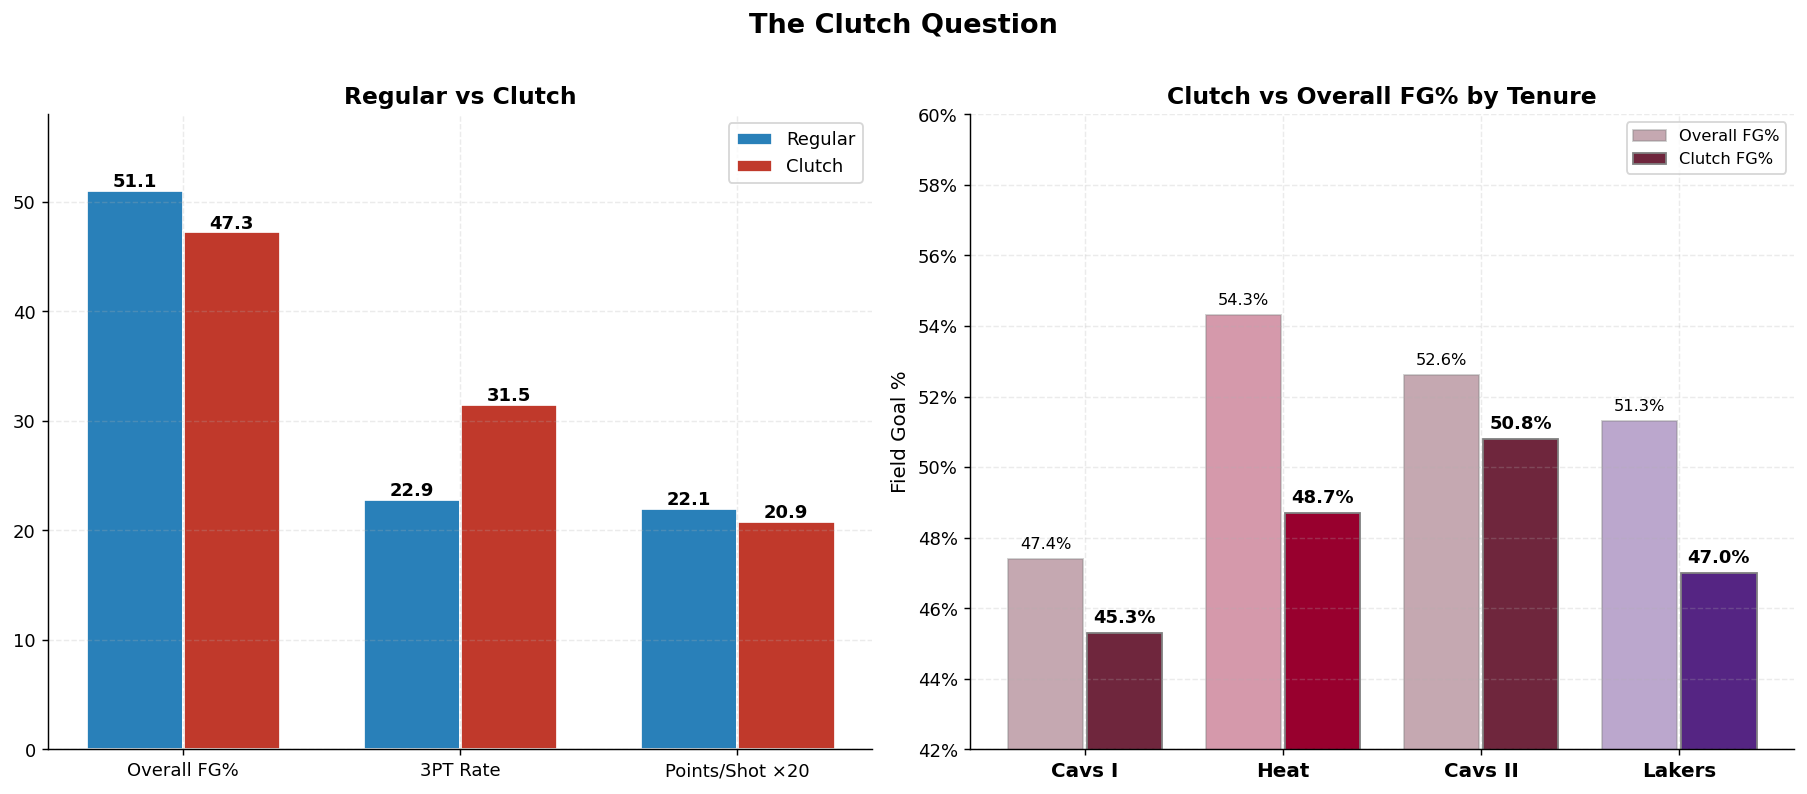

In [ ]:
clutch_rows = conn.execute("""
    SELECT situation, is_clutch_time, total_shots, fg_pct, three_pt_rate,
           points_per_shot, critical_time_shots, critical_fg_pct,
           final_possession_shots, final_possession_fg_pct,
           cavs1_fg_pct, heat_fg_pct, cavs2_fg_pct, lakers_fg_pct
    FROM main.mart_clutch_gene ORDER BY is_clutch_time DESC
""").fetchall()

clutch_r  = clutch_rows[0]
regular_r = clutch_rows[1]

categories    = ['Overall FG%', '3PT Rate', 'Points/Shot ×20']
clutch_vals   = [clutch_r[3],  clutch_r[4],  clutch_r[5]*20]
regular_vals  = [regular_r[3], regular_r[4], regular_r[5]*20]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Grouped bar: regular vs clutch ───────────────────────────────────────────
x, w = np.arange(3), 0.35
b1 = axes[0].bar(x - w/2, regular_vals, w, color=REGULAR_BLUE, label='Regular', edgecolor='white', lw=1.5)
b2 = axes[0].bar(x + w/2, clutch_vals,  w, color=CLUTCH_RED,   label='Clutch',  edgecolor='white', lw=1.5)

for bar, rv, cv in zip(b1, regular_vals, clutch_vals):
    pass  # labels below
for bars, vals, is_pps in [(b1, regular_vals, False), (b2, clutch_vals, False)]:
    for bar, v in zip(bars, vals):
        label = f'{v/20:.3f}' if bar.get_x() in [b.get_x() for b in b1[2:]] else f'{v:.1f}%'
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                     f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories, fontsize=10)
axes[0].set_title('Regular vs Clutch', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_ylim(0, 58)

# ── By-tenure clutch vs overall ───────────────────────────────────────────────
tenures_c     = ['Cavs I', 'Heat', 'Cavs II', 'Lakers']
clutch_by_t   = [clutch_r[10], clutch_r[11], clutch_r[12], clutch_r[13]]
overall_by_t  = [47.4, 54.3, 52.6, 51.3]
tc             = [TEAM_COLORS[t][0] for t in tenures_c]
x2 = np.arange(len(tenures_c))
axes[1].bar(x2 - 0.2, overall_by_t, 0.38, color=tc, alpha=0.4, edgecolor='grey', lw=1, label='Overall FG%')
axes[1].bar(x2 + 0.2, clutch_by_t,  0.38, color=tc, edgecolor='grey', lw=1, label='Clutch FG%')
for xi, cv, rv in zip(x2, clutch_by_t, overall_by_t):
    axes[1].text(xi + 0.2, cv + 0.3, f'{cv}%', ha='center', fontsize=10, fontweight='bold')
    axes[1].text(xi - 0.2, rv + 0.3, f'{rv}%', ha='center', fontsize=9)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(tenures_c, fontsize=11, fontweight='bold')
axes[1].set_ylabel('Field Goal %', fontsize=11)
axes[1].set_title('Clutch vs Overall FG% by Tenure', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(42, 60)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))

plt.suptitle("The Clutch Question", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Clutch breakdown table
clutch_summary = pd.DataFrame({
    'Situation':     ['Regular', 'Clutch', 'Critical (<2min)', 'Final Possession (<24s)'],
    'Shots':         [regular_r[2], clutch_r[2], clutch_r[6], clutch_r[8]],
    'FG%':           [regular_r[3], clutch_r[3], clutch_r[7], clutch_r[9]],
    '3PT Rate':      [regular_r[4], clutch_r[4], None, None],
    'Points/Shot':   [regular_r[5], clutch_r[5], None, None],
})
clutch_summary.style     .background_gradient(subset=['FG%'], cmap='RdYlGn', vmin=36, vmax=52)     .format({'FG%': '{:.1f}%', '3PT Rate': '{:.1f}%', 'Points/Shot': '{:.3f}',
             'Shots': '{:,.0f}'}, na_rep=' - ')     .set_caption('Clutch Situation Breakdown')

,Situation,Shots,FG%,3PT Rate,Points/Shot
0,Regular,"27,360",51.1%,22.9%,1.103
1,Clutch,"3,822",47.3%,31.5%,1.044
2,Critical (<2min),"1,744",44.6%,—,—
3,Final Possession (<24s),497,38.6%,—,—


## 6. Opponent Analysis

LeBron's most-faced opponents are almost all Eastern Conference teams from his Cleveland and Miami years. Chicago, Indiana, Atlanta, and Boston sit at the top - multiple playoff series account for the volume.

Best matchups (min 100 shots): Brooklyn (56.9%), Charlotte (53.9%), Portland (53.3%). Charlotte at 53.9% on 1,147 shots is the most meaningful - that's 20 years of evidence that the Hornets don't have an answer for him.

Toughest matchups (min 100 shots): LA Clippers (47.4%, 998 shots), Detroit (47.6%, 1,250 shots), Houston (48.5%, 927 shots). The Pistons number traces back to the 2005-2008 "LeBron Rules" playoff defense. Detroit's physical, gang-defensive scheme was the first sustained solution anyone found for him.


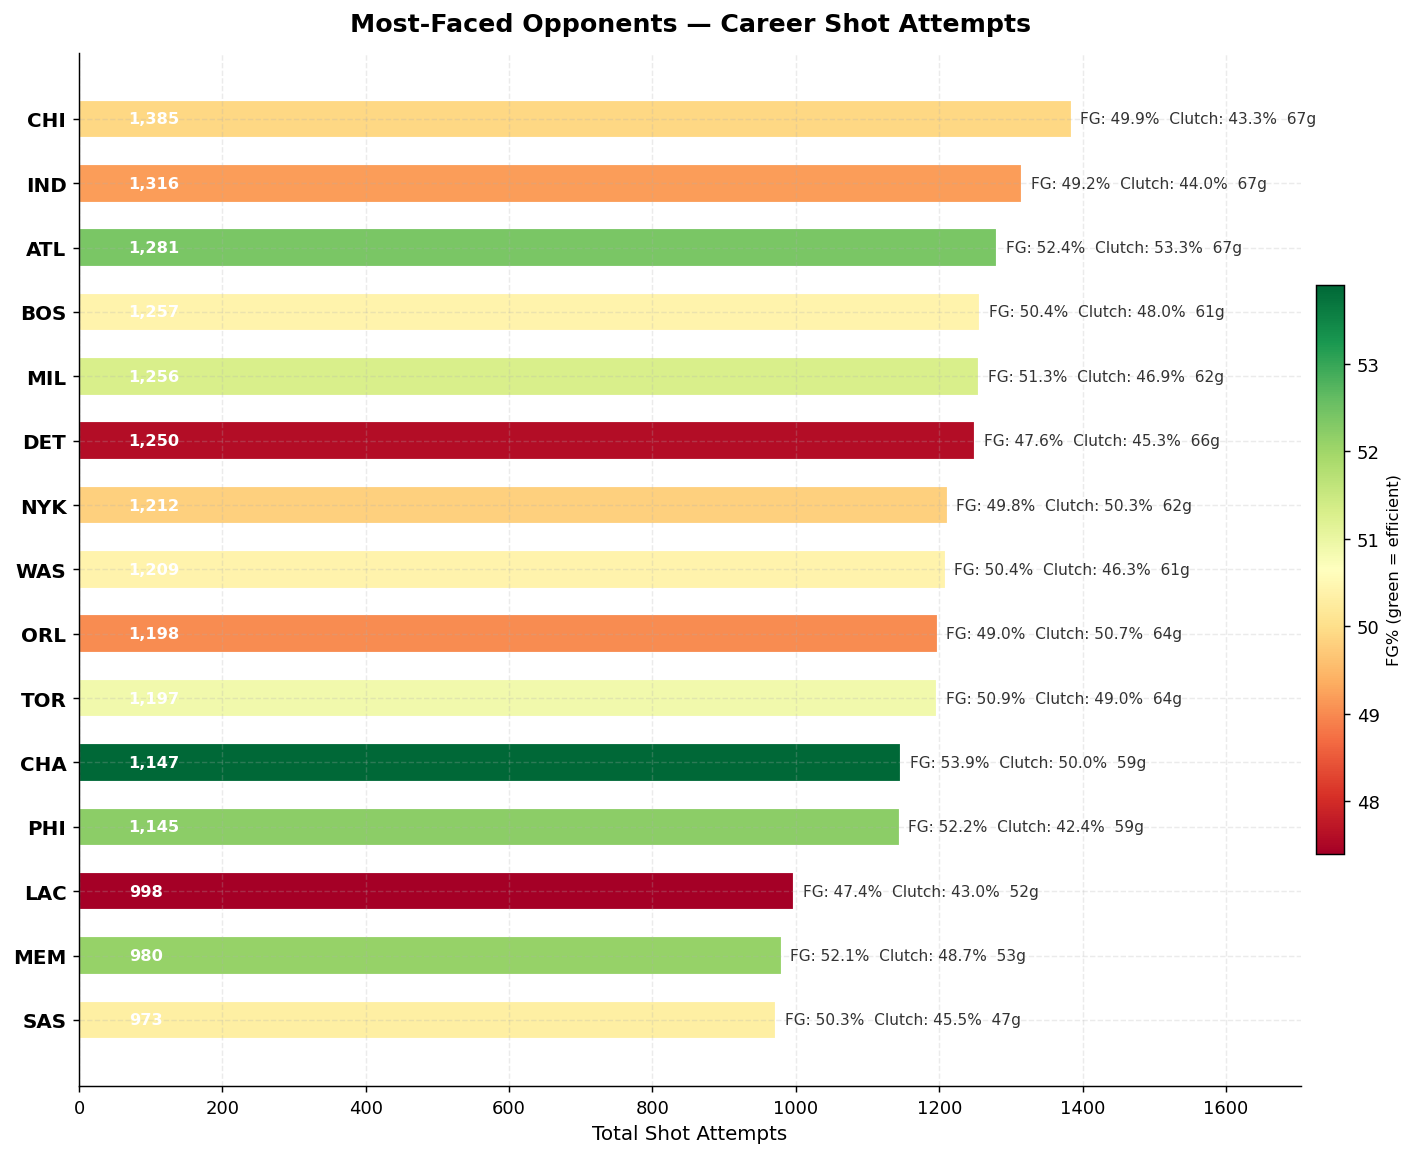

In [ ]:
opp_rows = conn.execute("""
    SELECT opponent_abbr, total_shots, games_played, fg_pct, clutch_fg_pct,
           three_pt_rate, home_fg_pct, away_fg_pct, rank_by_shots
    FROM main.mart_opponent_analysis
    GROUP BY opponent_abbr, total_shots, games_played, fg_pct, clutch_fg_pct,
             three_pt_rate, home_fg_pct, away_fg_pct, rank_by_shots
    ORDER BY rank_by_shots LIMIT 15
""").fetchall()

opps   = [r[0] for r in reversed(opp_rows)]
shots  = [r[1] for r in reversed(opp_rows)]
fgs    = [r[3] for r in reversed(opp_rows)]
cfgs   = [r[4] for r in reversed(opp_rows)]
games  = [r[2] for r in reversed(opp_rows)]

norm   = plt.Normalize(min(fgs), max(fgs))
colors = plt.cm.RdYlGn(norm(fgs))

fig, ax = plt.subplots(figsize=(12, 9))
y    = np.arange(len(opps))
bars = ax.barh(y, shots, color=colors, edgecolor='white', lw=1.2, height=0.6)
for i, (bar, fg, cfg, g) in enumerate(zip(bars, fgs, cfgs, games)):
    cfg_str = f'{cfg}%' if cfg else 'N/A'
    ax.text(bar.get_width() + 12, i,
            f'FG: {fg}%  Clutch: {cfg_str}  {g}g',
            va='center', fontsize=8.5, color='#333')
    ax.text(max(shots)*0.05, i, f'{shots[i]:,}',
            va='center', ha='left', fontsize=9, fontweight='bold', color='white')
ax.set_yticks(y)
ax.set_yticklabels(opps, fontsize=11, fontweight='bold')
ax.set_xlabel('Total Shot Attempts', fontsize=11)
ax.set_title('Most-Faced Opponents  -  Career Shot Attempts', fontsize=14, fontweight='bold', pad=12)
ax.set_xlim(0, max(shots) + 320)

sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.55, pad=0.01)
cbar.set_label('FG% (green = efficient)', fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Best and worst matchups
best_opp = conn.execute("""
    SELECT opponent_abbr, fg_pct, total_shots, games_played, clutch_fg_pct
    FROM main.mart_opponent_analysis
    GROUP BY opponent_abbr, fg_pct, total_shots, games_played, clutch_fg_pct
    HAVING total_shots >= 100
    ORDER BY fg_pct DESC LIMIT 5
""").df()

worst_opp = conn.execute("""
    SELECT opponent_abbr, fg_pct, total_shots, games_played, clutch_fg_pct
    FROM main.mart_opponent_analysis
    GROUP BY opponent_abbr, fg_pct, total_shots, games_played, clutch_fg_pct
    HAVING total_shots >= 100
    ORDER BY fg_pct ASC LIMIT 5
""").df()

print("BEST MATCHUPS (min 100 shots)")
display(best_opp.style.background_gradient(subset=['fg_pct'], cmap='Greens')
        .format({'fg_pct': '{:.1f}%', 'total_shots': '{:,}', 'clutch_fg_pct': '{:.1f}%'}))

print("\nTOUGHEST MATCHUPS (min 100 shots)")
display(worst_opp.style.background_gradient(subset=['fg_pct'], cmap='Reds_r')
        .format({'fg_pct': '{:.1f}%', 'total_shots': '{:,}', 'clutch_fg_pct': '{:.1f}%'}))

BEST MATCHUPS (min 100 shots)


,opponent_abbr,fg_pct,total_shots,games_played,clutch_fg_pct
0,BKN,56.9%,603,33,59.4%
1,CHA,53.9%,"1,147",59,50.0%
2,CLE,53.8%,472,25,46.9%
3,POR,53.3%,913,45,54.5%
4,NOP,53.0%,658,33,41.6%



TOUGHEST MATCHUPS (min 100 shots)


,opponent_abbr,fg_pct,total_shots,games_played,clutch_fg_pct
0,LAC,47.4%,998,52,43.0%
1,DET,47.6%,"1,250",66,45.3%
2,NOH,47.6%,309,17,46.2%
3,LAL,47.7%,633,30,46.8%
4,HOU,48.5%,927,48,38.9%


## 7. Shot Selection Evolution

The structural shift in where LeBron takes his shots is the clearest evidence of how he adapted to the analytics revolution.

What moved:
- At Rim (0 ft): 19.8% → 11.5%. Not athleticism declining - defenses load the paint differently and more shots from deep shrinks the rim share mathematically.
- Long Mid-range (17-23 ft): 23.7% → 11.5%. The analytics revolution in one number. Those pull-up 20-footers were the lowest expected-value shots in his game.
- Three-pointers (24+ ft): 17.0% → 26.4%. The whole transformation of modern basketball compressed into a single data point.

The court map shows heavy density around the restricted area, a secondary cluster at the elbow, and a third band at the three-point line - especially the corners.


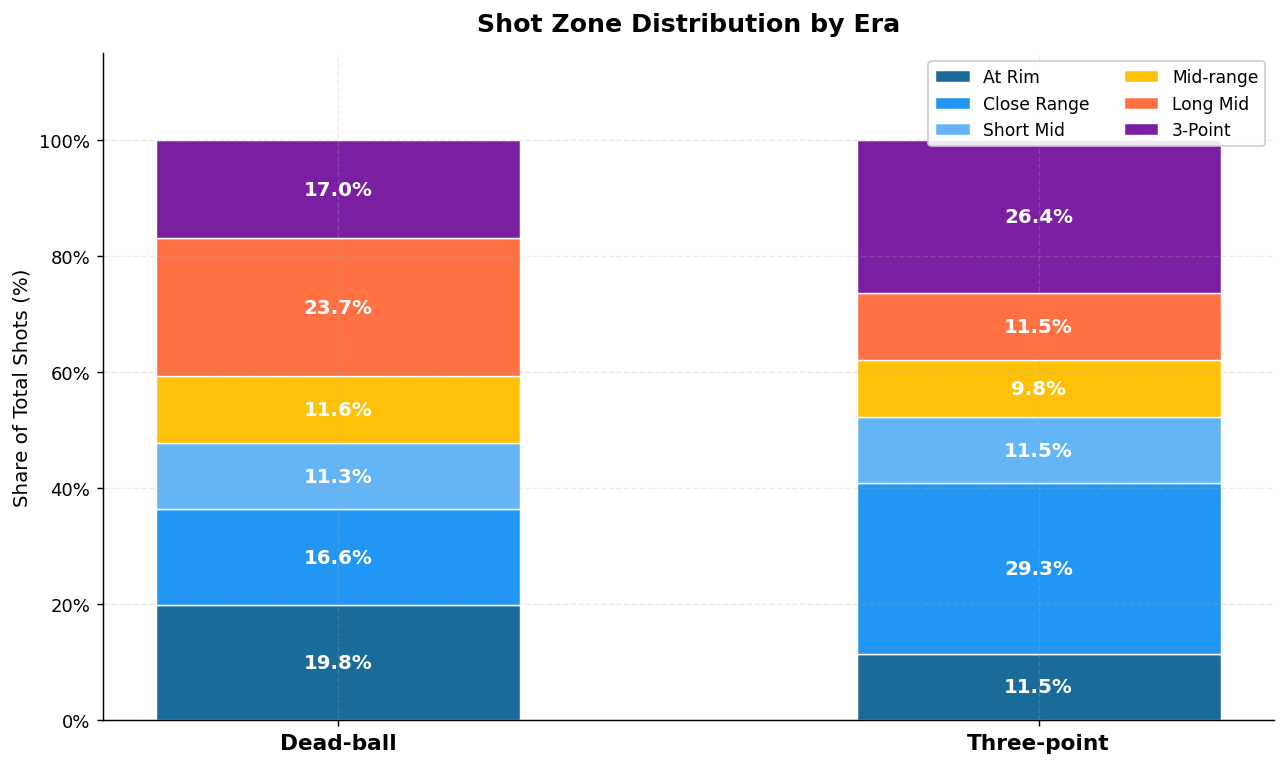

In [ ]:
dist_rows = conn.execute("""
    SELECT era,
           ROUND(shots_at_rim*100.0/total_shots, 1)        AS at_rim,
           ROUND(shots_close_range*100.0/total_shots, 1)   AS close_range,
           ROUND(shots_short_midrange*100.0/total_shots, 1) AS short_mid,
           ROUND(shots_midrange*100.0/total_shots, 1)      AS mid_range,
           ROUND(shots_long_midrange*100.0/total_shots, 1) AS long_mid,
           ROUND(shots_threepoint*100.0/total_shots, 1)    AS three_pt
    FROM main.mart_era_analysis
    GROUP BY era, shots_at_rim, total_shots, shots_close_range,
             shots_short_midrange, shots_midrange, shots_long_midrange, shots_threepoint
    ORDER BY era
""").fetchall()

zones     = ['At Rim', 'Close Range', 'Short Mid', 'Mid-range', 'Long Mid', '3-Point']
zone_clrs = ['#1A6B9A','#2196F3','#64B5F6','#FFC107','#FF7043','#7B1FA2']
eras_d    = [r[0] for r in dist_rows]
data_d    = [[r[i+1] for i in range(6)] for r in dist_rows]

fig, ax = plt.subplots(figsize=(10, 6))
x, w = np.arange(len(eras_d)), 0.52
cum  = np.zeros(len(eras_d))
for zi, (zone, clr) in enumerate(zip(zones, zone_clrs)):
    vals = np.array([d[zi] for d in data_d])
    ax.bar(x, vals, w, bottom=cum, color=clr, label=zone, edgecolor='white', lw=0.8)
    for xi, (v, b) in enumerate(zip(vals, cum)):
        if v >= 5.0:
            ax.text(xi, b + v/2, f'{v}%', ha='center', va='center',
                    fontsize=11, fontweight='bold', color='white')
    cum += vals
ax.set_xticks(x)
ax.set_xticklabels([e.replace(' Era', '') for e in eras_d], fontsize=12, fontweight='bold')
ax.set_ylabel('Share of Total Shots (%)', fontsize=11)
ax.set_title('Shot Zone Distribution by Era', fontsize=14, fontweight='bold', pad=12)
ax.legend(loc='upper right', ncol=2, fontsize=9.5, framealpha=0.9)
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))
plt.tight_layout()
plt.show()

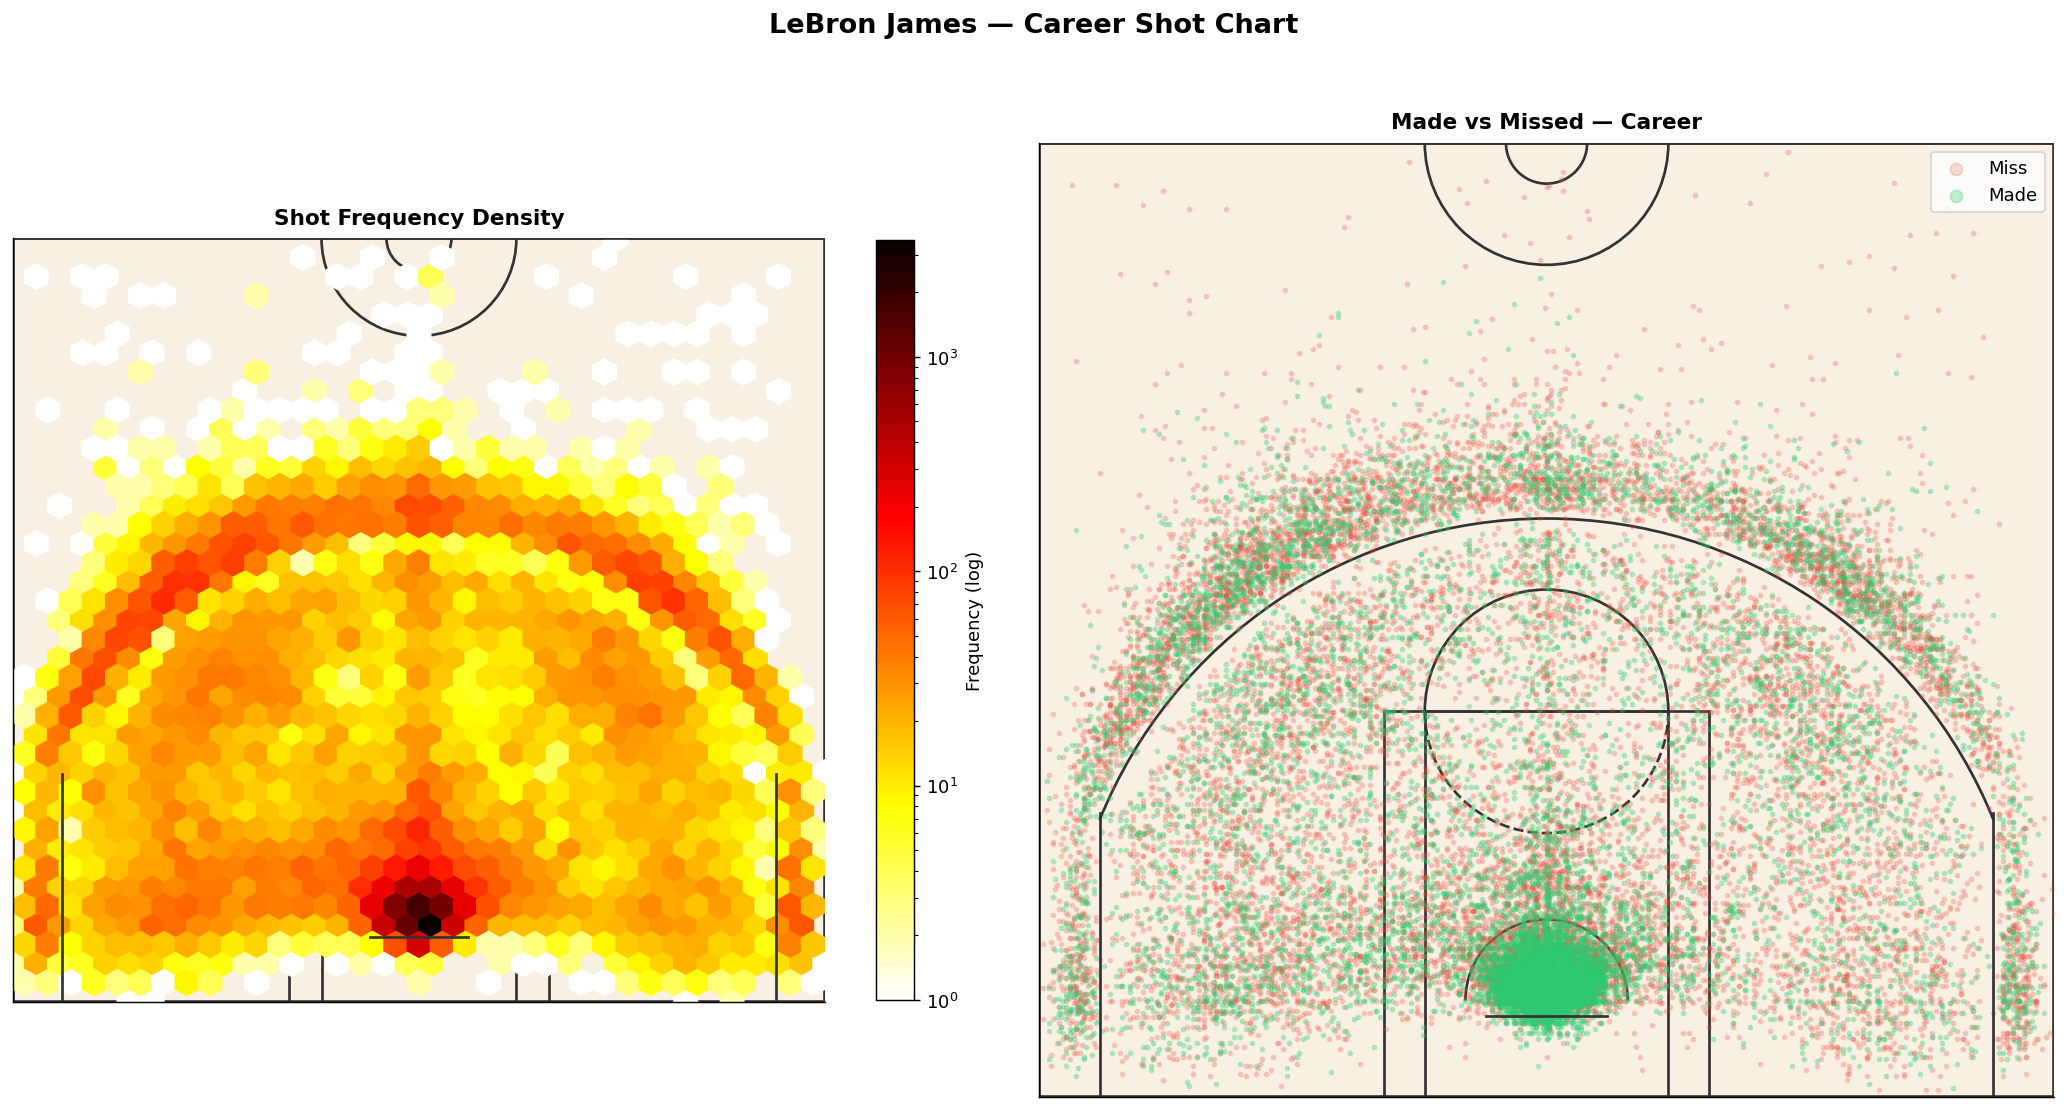

In [ ]:
# ── Court drawing helper ──────────────────────────────────────────────────────
def draw_court(ax, color='#333', lw=1.5):
    ax.set_facecolor('#F8F0E3')
    ax.add_patch(Circle((0,0), 7.5, lw=lw, color=color, fill=False))
    ax.add_line(plt.Line2D([-30,30], [-7.5,-7.5], lw=lw, color=color))
    ax.add_patch(Rectangle((-80,-47.5), 160, 190, lw=lw, color=color, fill=False))
    ax.add_patch(Rectangle((-60,-47.5), 120, 190, lw=lw, color=color, fill=False))
    ax.add_patch(Arc((0,142.5),120,120,theta1=0,theta2=180,lw=lw,color=color))
    ax.add_patch(Arc((0,142.5),120,120,theta1=180,theta2=0,lw=lw,color=color,ls='dashed'))
    ax.add_patch(Arc((0,0),80,80,theta1=0,theta2=180,lw=lw,color=color))
    ax.add_line(plt.Line2D([-220,-220],[-47.5,92.5],lw=lw,color=color))
    ax.add_line(plt.Line2D([220,220],[-47.5,92.5],lw=lw,color=color))
    ax.add_patch(Arc((0,0),475,475,theta1=22,theta2=158,lw=lw,color=color))
    ax.add_patch(Circle((0,422.5),60,lw=lw,color=color,fill=False))
    ax.add_patch(Circle((0,422.5),20,lw=lw,color=color,fill=False))
    ax.add_line(plt.Line2D([-250,250],[422.5,422.5],lw=lw,color=color))
    ax.add_patch(Rectangle((-250,-47.5),500,470,lw=lw+0.5,color=color,fill=False))
    ax.set_xlim(-250,250); ax.set_ylim(-47.5,422.5)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])

shots_raw = conn.execute("""
    SELECT loc_x, loc_y, is_shot_made::int AS made
    FROM main.stg_lebron_shots
    WHERE loc_x IS NOT NULL AND loc_y IS NOT NULL AND loc_y <= 422.5
""").fetchall()

lx   = np.array([s[0] for s in shots_raw], dtype=float)
ly   = np.array([s[1] for s in shots_raw], dtype=float)
made = np.array([s[2] for s in shots_raw], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
draw_court(axes[0])
hb = axes[0].hexbin(lx, ly, gridsize=35, mincnt=1, cmap='hot_r',
                    bins='log', extent=(-250,250,-47.5,422.5))
plt.colorbar(hb, ax=axes[0], label='Frequency (log)', shrink=0.7)
axes[0].set_title('Shot Frequency Density', fontsize=12, fontweight='bold', pad=8)

draw_court(axes[1])
axes[1].scatter(lx[made==0], ly[made==0], c='#E74C3C', alpha=0.2, s=5, label='Miss', rasterized=True)
axes[1].scatter(lx[made==1], ly[made==1], c='#2ECC71', alpha=0.28, s=5, label='Made', rasterized=True)
axes[1].legend(markerscale=3, fontsize=10, loc='upper right')
axes[1].set_title('Made vs Missed  -  Career', fontsize=12, fontweight='bold', pad=8)

fig.suptitle("LeBron James  -  Career Shot Chart", fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 8. Career Trajectory

The career FG% arc has three phases:

1. Rise (2003-2014): Rookie season at 41.7%, steadily climbing through the Miami peak at 56.7% in 2013-14. That single season is one of the five best FG% seasons ever recorded for a player averaging 25+ points per game.

2. Reset (2014-2016): Returned to Cleveland, started launching more threes. The volume of threes pulled his overall FG% back down from the Miami peak even as his 2-point efficiency stayed high.

3. Stabilization (2016-present): Settled into the 49-54% range with the Lakers. The 2023-24 season at 54.0% - his best as a Laker - came at age 39.

Championship seasons (highlighted in gold) don't show a consistent FG% premium. Winning requires good efficiency, not peak efficiency.


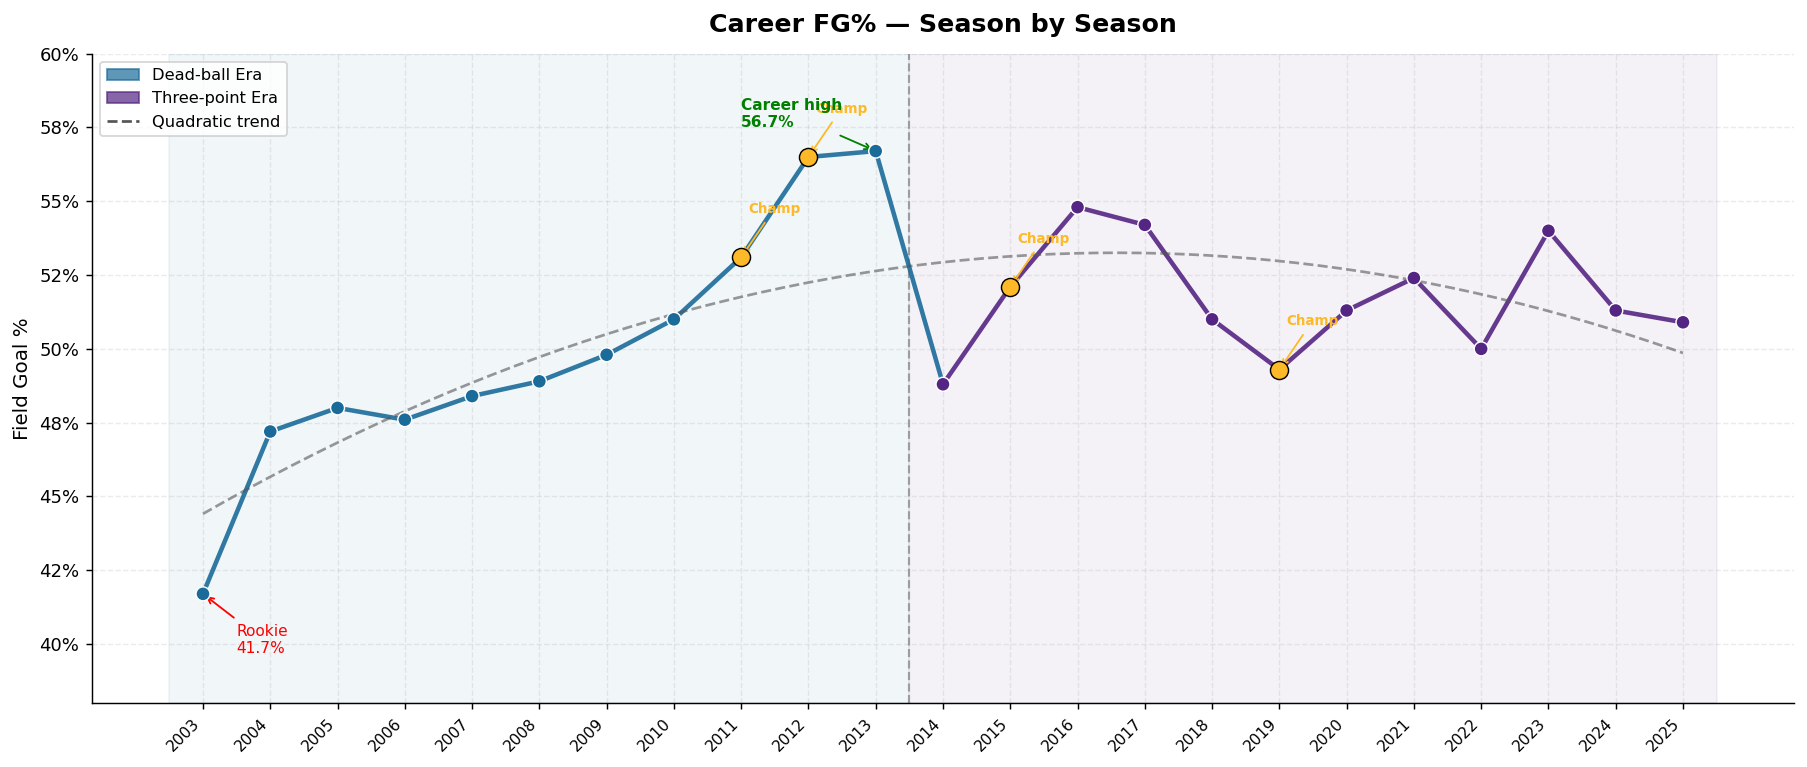

In [ ]:
traj_rows = conn.execute("""
    SELECT season, season_start_year, era, season_fg_pct, season_shots
    FROM main.mart_era_analysis
    GROUP BY season, season_start_year, era, season_fg_pct, season_shots
    ORDER BY season_start_year
""").fetchall()

seasons_t = [r[0] for r in traj_rows]
fgs_t     = [r[3] for r in traj_rows]
eras_t    = [r[2] for r in traj_rows]
x_t = np.arange(len(seasons_t))
clrs_t = [ERA_DEAD if e == 'Dead-ball Era' else ERA_THREE for e in eras_t]

champ = {'2011-12','2012-13','2015-16','2019-20'}

fig, ax = plt.subplots(figsize=(14, 6))
ax.axvspan(-0.5, 10.5, alpha=0.06, color=ERA_DEAD)
ax.axvspan(10.5, len(seasons_t)-0.5, alpha=0.06, color=ERA_THREE)
ax.axvline(10.5, color='grey', lw=1.2, ls='--', alpha=0.7)

for i in range(len(x_t)-1):
    ax.plot(x_t[i:i+2], fgs_t[i:i+2], color=clrs_t[i], lw=2.5, alpha=0.9)
ax.scatter(x_t, fgs_t, c=clrs_t, zorder=5, s=60, edgecolors='white', lw=0.8)

for s, xi, fg in zip(seasons_t, x_t, fgs_t):
    if s in champ:
        ax.annotate('Champ', xy=(xi, fg), xytext=(xi+0.1, fg+1.5),
                    fontsize=7.5, color=GOLD, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=GOLD, lw=1))
        ax.scatter([xi], [fg], c=GOLD, zorder=6, s=100, edgecolors='black', lw=0.8)

z = np.polyfit(x_t, fgs_t, 2)
xn = np.linspace(0, len(x_t)-1, 200)
ax.plot(xn, np.poly1d(z)(xn), '--', color='#555', lw=1.5, alpha=0.6, label='Trend (quadratic)')

peak_i = int(np.argmax(fgs_t))
low_i  = int(np.argmin(fgs_t))
ax.annotate(f'Career high\n{fgs_t[peak_i]}%', xy=(x_t[peak_i], fgs_t[peak_i]),
            xytext=(x_t[peak_i]-2, fgs_t[peak_i]+0.8), fontsize=8.5, color='green',
            fontweight='bold', arrowprops=dict(arrowstyle='->', color='green', lw=1))
ax.annotate(f'Rookie\n{fgs_t[low_i]}%', xy=(x_t[low_i], fgs_t[low_i]),
            xytext=(x_t[low_i]+0.5, fgs_t[low_i]-2), fontsize=8.5, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1))

ax.set_xticks(x_t)
ax.set_xticklabels([s[:4] for s in seasons_t], rotation=45, ha='right', fontsize=8.5)
ax.set_ylabel('Field Goal %', fontsize=11)
ax.set_title("Career FG%  -  Season by Season", fontsize=14, fontweight='bold', pad=12)
ax.set_ylim(38, 60)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))

dead_p  = mpatches.Patch(color=ERA_DEAD,  alpha=0.7, label='Dead-ball Era')
three_p = mpatches.Patch(color=ERA_THREE, alpha=0.7, label='Three-point Era')
trend_l = plt.Line2D([0],[0], color='#555', lw=1.5, ls='--', label='Quadratic trend')
ax.legend(handles=[dead_p, three_p, trend_l], fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

## 9. The Best Season

Twenty-three seasons produce a lot of data points. This section isolates the best season in three separate dimensions - volume, scoring, and effectiveness - and then compares them to show which seasons dominate across multiple categories.

The three dimensions measure fundamentally different things:
- Volume - how many shots did he take? Reflects usage, role, and team context.
- Scoring - how many field-goal points did he produce? Volume × efficiency combined.
- Effectiveness - how well did he convert? FG% and points-per-shot.

A season that ranks high in all three is rare. The analysis shows why.


In [ ]:
# Load the full best_seasons mart
bs_rows = conn.execute("""
    SELECT season, season_start_year, tenure, era,
           total_shots, shots_per_game, games_played,
           fg_pct, fg2_pct, fg3_pct, three_pt_rate,
           total_points, points_per_game, points_per_shot,
           avg_shot_distance, home_fg_pct, away_fg_pct, clutch_fg_pct,
           rank_by_shots, rank_by_points, rank_by_fg_pct, rank_by_pps
    FROM main.mart_best_seasons
    ORDER BY season_start_year
""").fetchall()

# Build a DataFrame for table work
COLS = ['season','year','tenure','era',
        'total_shots','shots_per_game','games',
        'fg_pct','fg2_pct','fg3_pct','three_pt_rate',
        'total_points','points_per_game','points_per_shot',
        'avg_dist','home_fg','away_fg','clutch_fg',
        'rank_shots','rank_points','rank_fg','rank_pps']
bs_df = pd.DataFrame(bs_rows, columns=COLS)

print(f"Seasons loaded: {len(bs_df)}")
print(f"Career span: {bs_df['season'].iloc[0]} - {bs_df['season'].iloc[-1]}")

Seasons loaded: 23
Career span: 2003-04 - 2025-26


### 9.1 Overview: Top 8 in Each Dimension

Three side-by-side panels show the ranking leaders for volume, scoring, and effectiveness. Bars are colored by team tenure.


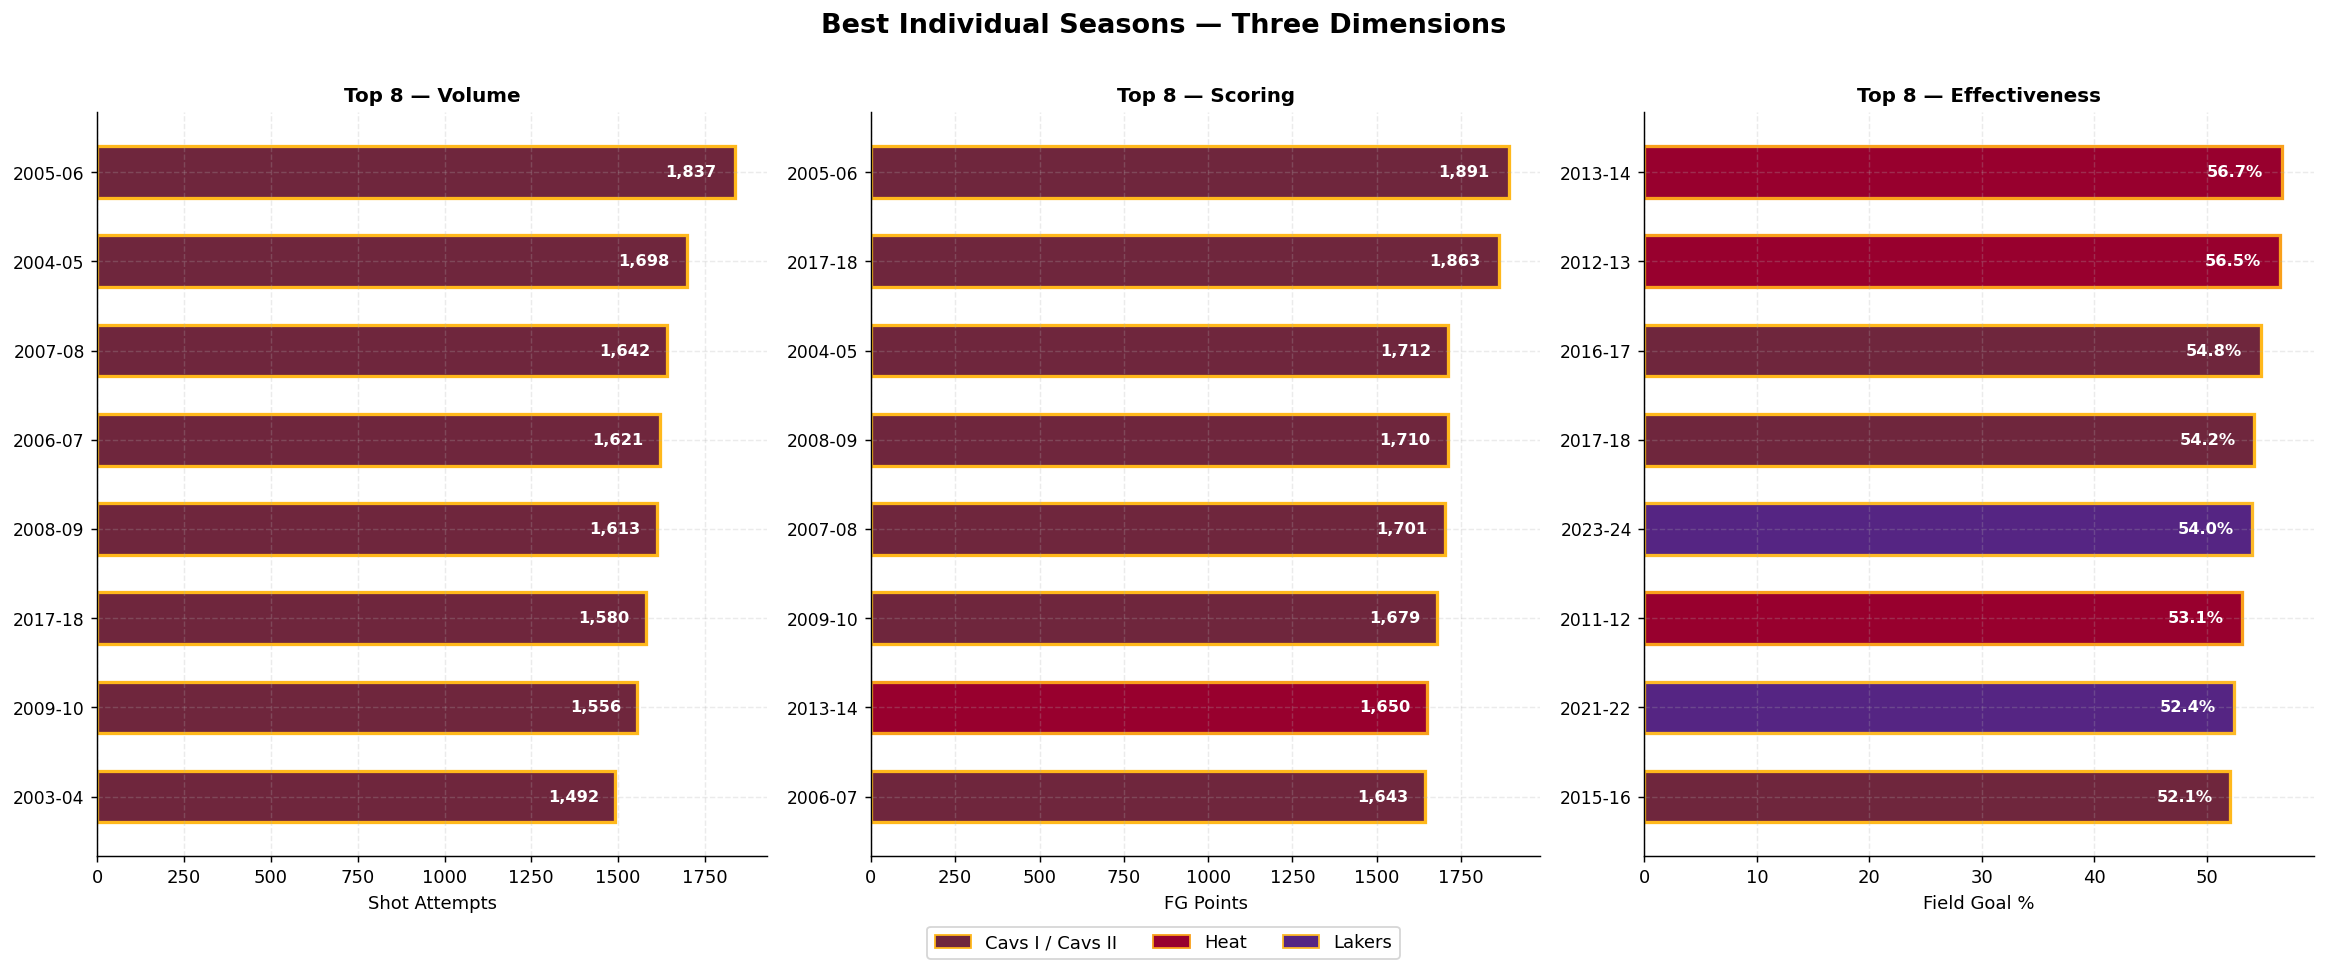

In [ ]:
def hbar(ax, data, val_idx, xlabel, title, fmt='{:,.0f}'):
    labels    = [r[0] for r in reversed(data)]
    vals      = [r[val_idx] for r in reversed(data)]
    tenures_h = [r[2] for r in reversed(data)]
    fc = [TEAM_COLORS.get(t,(PURPLE,GOLD))[0] for t in tenures_h]
    ec = [TEAM_COLORS.get(t,(PURPLE,GOLD))[1] for t in tenures_h]
    y  = np.arange(len(labels))
    bars = ax.barh(y, vals, color=fc, edgecolor=ec, linewidth=1.8, height=0.58)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width()*0.97, bar.get_y() + bar.get_height()/2,
                fmt.format(v), va='center', ha='right', fontsize=9,
                fontweight='bold', color='white')
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=9.5)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=6)

by_shots = sorted(bs_rows, key=lambda r: r[18])[:8]   # rank_by_shots
by_pts   = sorted(bs_rows, key=lambda r: r[19])[:8]   # rank_by_points
by_fg    = sorted(bs_rows, key=lambda r: r[20])[:8]   # rank_by_fg_pct

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
hbar(axes[0], by_shots, 4,  'Shot Attempts',     'Top 8  -  Volume')
hbar(axes[1], by_pts,   11, 'FG Points',         'Top 8  -  Scoring')
hbar(axes[2], by_fg,    7,  'Field Goal %',      'Top 8  -  Effectiveness', fmt='{:.1f}%')

legend_handles = [
    mpatches.Patch(facecolor=CAVS_WINE, edgecolor=CAVS_GOLD, label='Cavs I / Cavs II'),
    mpatches.Patch(facecolor=HEAT_RED,  edgecolor='#F9A01B', label='Heat'),
    mpatches.Patch(facecolor=PURPLE,    edgecolor=GOLD,       label='Lakers'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.04))
plt.suptitle("Best Individual Seasons  -  Three Dimensions", fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 9.2 By Volume: The Cavs I Years

LeBron's five highest-shot seasons all come from Cavs I (2003-2010). The Cleveland roster had no reliable second scorer - defenses could key entirely on him, and the coaching staff still ran every half-court set through him regardless.

The tradeoff is visible: his top volume season (2005-06, 1,837 attempts) came with a 48.0% FG - well below his 50.6% career average. High usage against prepared defenses suppresses efficiency. By Miami, his volume dropped and his efficiency jumped because defenses had to split their attention between him, Wade, and Bosh.

The trend is clear: once he had quality teammates, his shot volume shrank and his conversion rate improved. The two variables move in opposite directions across his career.


In [ ]:
top_vol = bs_df.nsmallest(10, 'rank_shots')[
    ['season','tenure','total_shots','shots_per_game','games','fg_pct','three_pt_rate',
     'total_points','points_per_game']
].reset_index(drop=True)

top_vol.index += 1  # rank from 1

display(top_vol.style
    .background_gradient(subset=['total_shots'], cmap='Blues')
    .background_gradient(subset=['fg_pct'],      cmap='RdYlGn', vmin=41, vmax=56)
    .format({
        'total_shots':    '{:,}',
        'shots_per_game': '{:.1f}',
        'fg_pct':         '{:.1f}%',
        'three_pt_rate':  '{:.1f}%',
        'total_points':   '{:,}',
        'points_per_game':'{:.1f}',
    })
    .set_caption('Top 10 Seasons by Shot Volume'))

,season,tenure,total_shots,shots_per_game,games,fg_pct,three_pt_rate,total_points,points_per_game
1,2005-06,Cavs I,"1,837",23.3,79,48.0%,20.6%,"1,891",23.9
2,2004-05,Cavs I,"1,698",21.2,80,47.2%,18.1%,"1,712",21.4
3,2007-08,Cavs I,"1,642",21.9,75,48.4%,21.9%,"1,701",22.7
4,2006-07,Cavs I,"1,621",20.8,78,47.6%,19.1%,"1,643",21.1
5,2008-09,Cavs I,"1,613",19.9,81,48.9%,23.8%,"1,710",21.1
6,2017-18,Cavs II,"1,580",19.3,82,54.2%,25.7%,"1,863",22.7
7,2009-10,Cavs I,"1,556",20.5,76,49.8%,24.9%,"1,679",22.1
8,2003-04,Cavs I,"1,492",18.9,79,41.7%,14.5%,"1,307",16.5
9,2010-11,Heat,"1,485",18.8,79,51.0%,18.8%,"1,608",20.4
10,2015-16,Cavs II,"1,415",18.6,76,52.1%,19.9%,"1,561",20.5


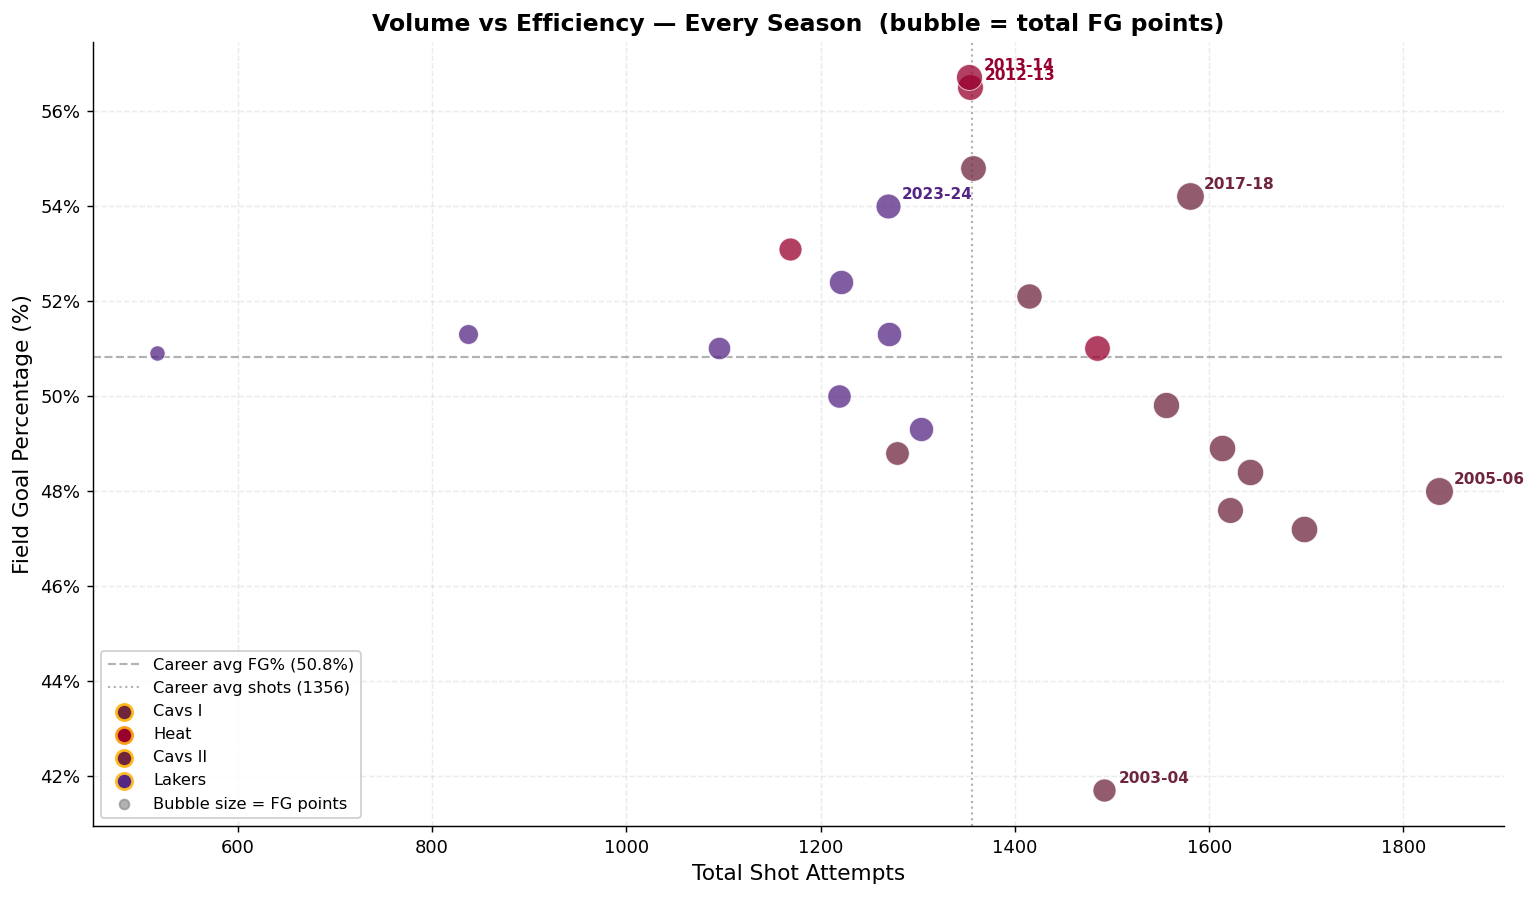

In [ ]:
# Volume vs efficiency scatter  -  shows the tradeoff visually
fig, ax = plt.subplots(figsize=(12, 7))

for _, row in bs_df.iterrows():
    fc = TEAM_COLORS.get(row['tenure'], (PURPLE, GOLD))[0]
    ax.scatter(row['total_shots'], row['fg_pct'], color=fc,
               s=row['total_points']/8, alpha=0.75, edgecolors='white', lw=0.5, zorder=3)

# label interesting seasons
label_seasons = {'2005-06','2013-14','2012-13','2017-18','2023-24','2003-04'}
for _, row in bs_df.iterrows():
    if row['season'] in label_seasons:
        ax.annotate(row['season'],
                    xy=(row['total_shots'], row['fg_pct']),
                    xytext=(8, 4), textcoords='offset points',
                    fontsize=8.5, fontweight='bold',
                    color=TEAM_COLORS.get(row['tenure'],(PURPLE,GOLD))[0])

ax.axhline(bs_df['fg_pct'].mean(), color='grey', lw=1.2, ls='--', alpha=0.6,
           label=f"Career avg FG% ({bs_df['fg_pct'].mean():.1f}%)")
ax.axvline(bs_df['total_shots'].mean(), color='grey', lw=1.2, ls=':', alpha=0.6,
           label=f"Career avg shots ({bs_df['total_shots'].mean():.0f})")

# legend for tenures
for t, (fc, ec) in TEAM_COLORS.items():
    ax.scatter([], [], color=fc, edgecolors=ec, lw=1.5, s=80, label=t)
ax.scatter([], [], color='grey', s=30,  alpha=0.6, label='Bubble size = FG points')
ax.scatter([], [], color='grey', s=120, alpha=0.6, label='')

ax.set_xlabel('Total Shot Attempts', fontsize=12)
ax.set_ylabel('Field Goal Percentage (%)', fontsize=12)
ax.set_title('Volume vs Efficiency  -  Every Season  (bubble = total FG points)',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))
ax.legend(fontsize=9, loc='lower left', framealpha=0.9)
plt.tight_layout()
plt.show()

### 9.3 By Scoring: Total Field-Goal Points

Total points from the field rewards both volume and efficiency. The 2005-06 season tops the list (1,891 pts, 23.9/game) because volume carries it there at 48.0% FG.

The more instructive entry is 2017-18 at #2. LeBron produced 1,863 field-goal points on 1,580 shots - 257 fewer attempts than 2005-06 - at 54.2% FG. Nearly identical total output, generated through efficiency rather than volume. That's LeBron at 33, his final Cleveland season, carrying a team to the Finals while shooting at an elite rate.

Miami seasons are conspicuously absent from the top five, despite having his highest FG%. The reason: fewer games (shortened 2011-12 season) and lower usage - Spoelstra's system deliberately reduced his volume to maximize his shot quality. Fewer shots means fewer total points even at peak efficiency.


In [ ]:
top_pts = bs_df.nsmallest(10, 'rank_points')[
    ['season','tenure','total_points','points_per_game','total_shots',
     'fg_pct','points_per_shot']
].reset_index(drop=True)

top_pts.index += 1

display(top_pts.style
    .background_gradient(subset=['total_points'],   cmap='Purples')
    .background_gradient(subset=['points_per_shot'],cmap='RdYlGn', vmin=0.87, vmax=1.22)
    .background_gradient(subset=['fg_pct'],         cmap='RdYlGn', vmin=41, vmax=57)
    .format({
        'total_points':   '{:,}',
        'points_per_game':'{:.1f}',
        'total_shots':    '{:,}',
        'fg_pct':         '{:.1f}%',
        'points_per_shot':'{:.3f}',
    })
    .set_caption('Top 10 Seasons by Total FG Points'))

,season,tenure,total_points,points_per_game,total_shots,fg_pct,points_per_shot
1,2005-06,Cavs I,"1,891",23.9,"1,837",48.0%,1.029
2,2017-18,Cavs II,"1,863",22.7,"1,580",54.2%,1.179
3,2004-05,Cavs I,"1,712",21.4,"1,698",47.2%,1.008
4,2008-09,Cavs I,"1,710",21.1,"1,613",48.9%,1.060
5,2007-08,Cavs I,"1,701",22.7,"1,642",48.4%,1.036
6,2009-10,Cavs I,"1,679",22.1,"1,556",49.8%,1.079
7,2013-14,Heat,"1,650",21.4,"1,353",56.7%,1.220
8,2006-07,Cavs I,"1,643",21.1,"1,621",47.6%,1.014
9,2012-13,Heat,"1,633",21.5,"1,354",56.5%,1.206
10,2016-17,Cavs II,"1,610",21.8,"1,357",54.8%,1.186


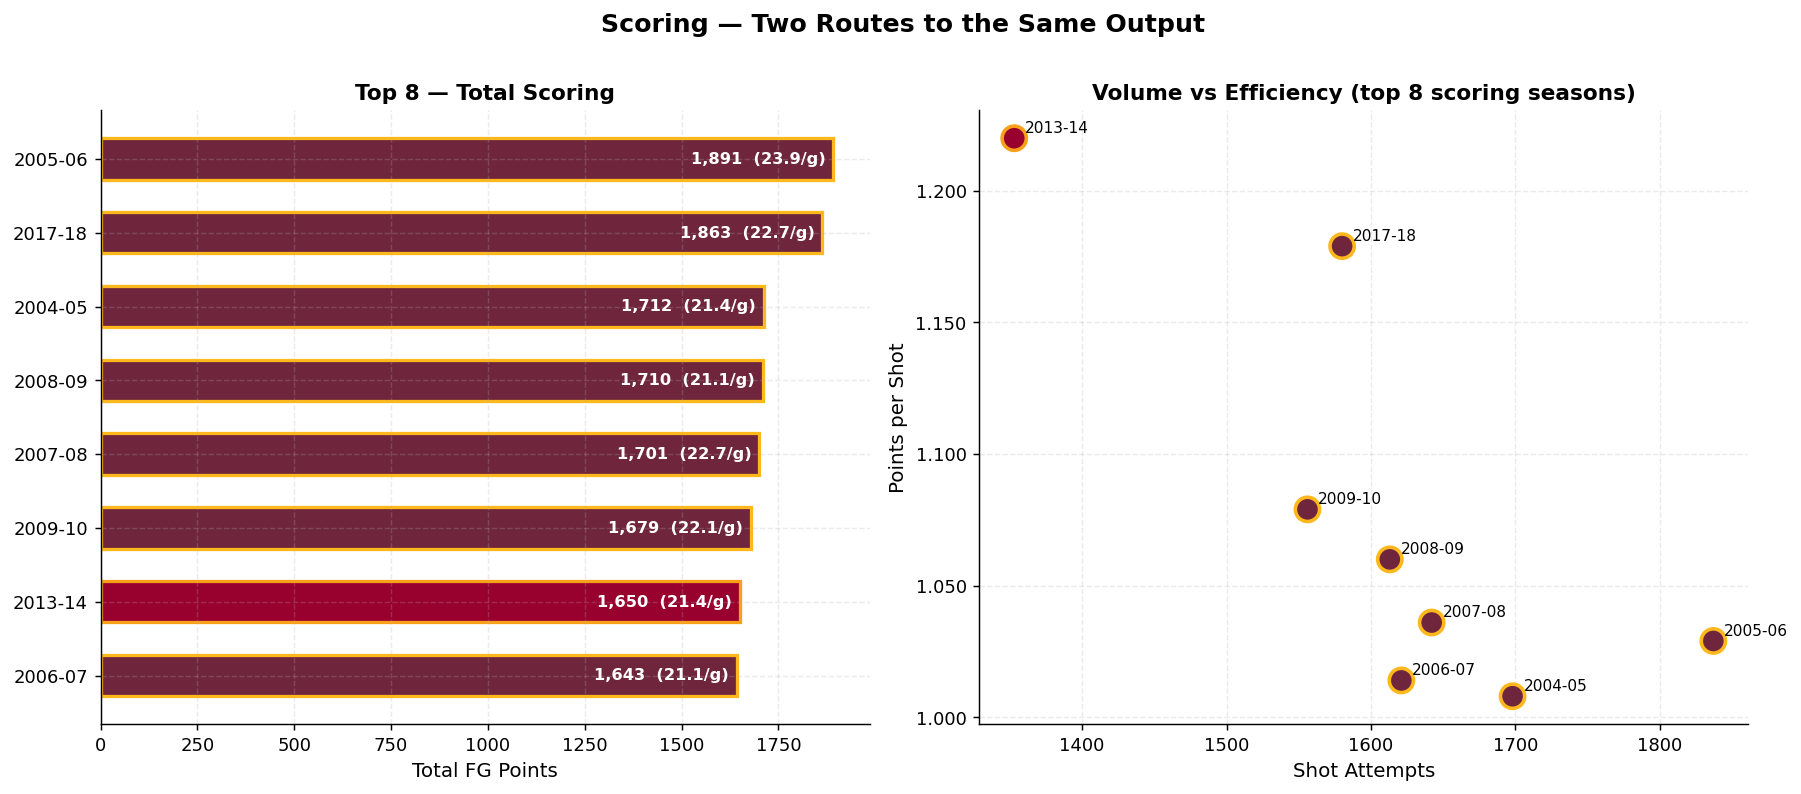

In [ ]:
# Stacked bar: shots × FG% decomposition for top 8 scoring seasons
top8_pts = bs_df.nsmallest(8, 'rank_points').sort_values('total_points', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left: total points bar with shots overlay
y = np.arange(len(top8_pts))
fc = [TEAM_COLORS.get(t,(PURPLE,GOLD))[0] for t in top8_pts['tenure']]
ec = [TEAM_COLORS.get(t,(PURPLE,GOLD))[1] for t in top8_pts['tenure']]

axes[0].barh(y, top8_pts['total_points'], color=fc, edgecolor=ec, lw=1.8, height=0.56)
for i, (pts, spg, fg) in enumerate(zip(top8_pts['total_points'],
                                        top8_pts['points_per_game'],
                                        top8_pts['fg_pct'])):
    axes[0].text(pts - 20, i, f'{pts:,}  ({spg:.1f}/g)',
                 va='center', ha='right', fontsize=9, fontweight='bold', color='white')
axes[0].set_yticks(y)
axes[0].set_yticklabels(top8_pts['season'], fontsize=10)
axes[0].set_xlabel('Total FG Points', fontsize=11)
axes[0].set_title('Top 8  -  Total Scoring', fontsize=12, fontweight='bold')

# right: shots vs points_per_shot  -  shows the two routes to scoring
axes[1].scatter(top8_pts['total_shots'], top8_pts['points_per_shot'],
                color=fc, edgecolors=ec, s=180, lw=2, zorder=3)
for _, row in top8_pts.iterrows():
    axes[1].annotate(row['season'],
                     xy=(row['total_shots'], row['points_per_shot']),
                     xytext=(6, 3), textcoords='offset points', fontsize=8.5)
axes[1].set_xlabel('Shot Attempts', fontsize=11)
axes[1].set_ylabel('Points per Shot', fontsize=11)
axes[1].set_title('Volume vs Efficiency (top 8 scoring seasons)', fontsize=12, fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.3f}'))

plt.suptitle("Scoring  -  Two Routes to the Same Output", fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 9.4 By Effectiveness: FG% and Points Per Shot

Ranked by FG%, the top two seasons are both from Miami. 2013-14 (56.7% FG, 1.220 pts/shot) and 2012-13 (56.5%, 1.206 pts/shot). These are the seasons where shot selection, system fit, and physical prime aligned. Low three-point rate (22.6% and 18.8%), high 2-point conversion (62.2% and 60.2%), very few long mid-range attempts.

Then two Cavs II seasons (2016-17 and 2017-18), both above 54%.

The outlier that deserves separate attention: 2023-24 at #5 in FG% (54.0%) and #3 in points-per-shot (1.197), at age 39. He shot 28.6% from three at 41.0% from deep - a shot profile that didn't exist in his Miami years. The method is completely different; the output is nearly identical to those two Heat peaks. That's the adaptation story in a single row.


In [ ]:
top_eff = bs_df.nsmallest(10, 'rank_fg')[
    ['season','tenure','fg_pct','fg2_pct','fg3_pct','three_pt_rate',
     'points_per_shot','avg_dist','clutch_fg']
].reset_index(drop=True)

top_eff.index += 1

display(top_eff.style
    .background_gradient(subset=['fg_pct'],        cmap='RdYlGn', vmin=47, vmax=57)
    .background_gradient(subset=['points_per_shot'],cmap='RdYlGn', vmin=0.87, vmax=1.22)
    .background_gradient(subset=['three_pt_rate'],  cmap='Blues')
    .format({
        'fg_pct':         '{:.1f}%',
        'fg2_pct':        '{:.1f}%',
        'fg3_pct':        '{:.1f}%',
        'three_pt_rate':  '{:.1f}%',
        'points_per_shot':'{:.3f}',
        'avg_dist':       '{:.1f} ft',
        'clutch_fg':      '{:.1f}%',
    })
    .set_caption('Top 10 Seasons by FG%'))

,season,tenure,fg_pct,fg2_pct,fg3_pct,three_pt_rate,points_per_shot,avg_dist,clutch_fg
1,2013-14,Heat,56.7%,62.2%,37.9%,22.6%,1.220,10.9 ft,53.6%
2,2012-13,Heat,56.5%,60.2%,40.6%,18.8%,1.206,10.8 ft,49.1%
3,2016-17,Cavs II,54.8%,60.9%,36.4%,25.1%,1.186,10.4 ft,51.4%
4,2017-18,Cavs II,54.2%,60.3%,36.7%,25.7%,1.179,11.0 ft,51.8%
5,2023-24,Lakers,54.0%,59.2%,41.0%,28.6%,1.197,11.2 ft,52.6%
6,2011-12,Heat,53.1%,55.6%,36.2%,12.7%,1.109,11.0 ft,43.3%
7,2021-22,Lakers,52.4%,62.0%,35.9%,36.7%,1.180,13.3 ft,44.4%
8,2015-16,Cavs II,52.1%,57.3%,31.0%,19.9%,1.103,9.6 ft,50.3%
9,2020-21,Lakers,51.3%,58.9%,36.5%,34.1%,1.149,13.2 ft,44.3%
10,2024-25,Lakers,51.3%,57.4%,37.6%,31.2%,1.143,12.9 ft,49.6%


In [ ]:
# Miami 2013-14 vs Lakers 2023-24: same output, different method
compare = bs_df[bs_df['season'].isin(['2013-14','2023-24'])].set_index('season')
metrics = ['fg_pct','fg2_pct','fg3_pct','three_pt_rate',
           'points_per_shot','avg_dist','total_shots','clutch_fg']
labels  = ['FG%','2PT%','3PT%','3PT Rate','Pts/Shot','Avg Dist','Shots','Clutch FG%']

compare_t = compare[metrics].T.copy()
compare_t.index = labels

print("Miami 2013-14 vs Lakers 2023-24  -  Same efficiency, different approach\n")
display(compare_t.style
    .background_gradient(cmap='RdYlGn', axis=1)
    .format(lambda v: f'{v:.1f}%' if v > 1.5 else f'{v:.3f}' if v < 2 else f'{v:,.0f}')
    .set_caption('Peak Season Comparison: 2013-14 (Heat) vs 2023-24 (Lakers)'))

Miami 2013-14 vs Lakers 2023-24  -  Same efficiency, different approach



season,2013-14,2023-24
FG%,56.7%,54.0%
2PT%,62.2%,59.2%
3PT%,37.9%,41.0%
3PT Rate,22.6%,28.6%
Pts/Shot,1.220,1.197
Avg Dist,10.9%,11.2%
Shots,1353.0%,1269.0%
Clutch FG%,53.6%,52.6%


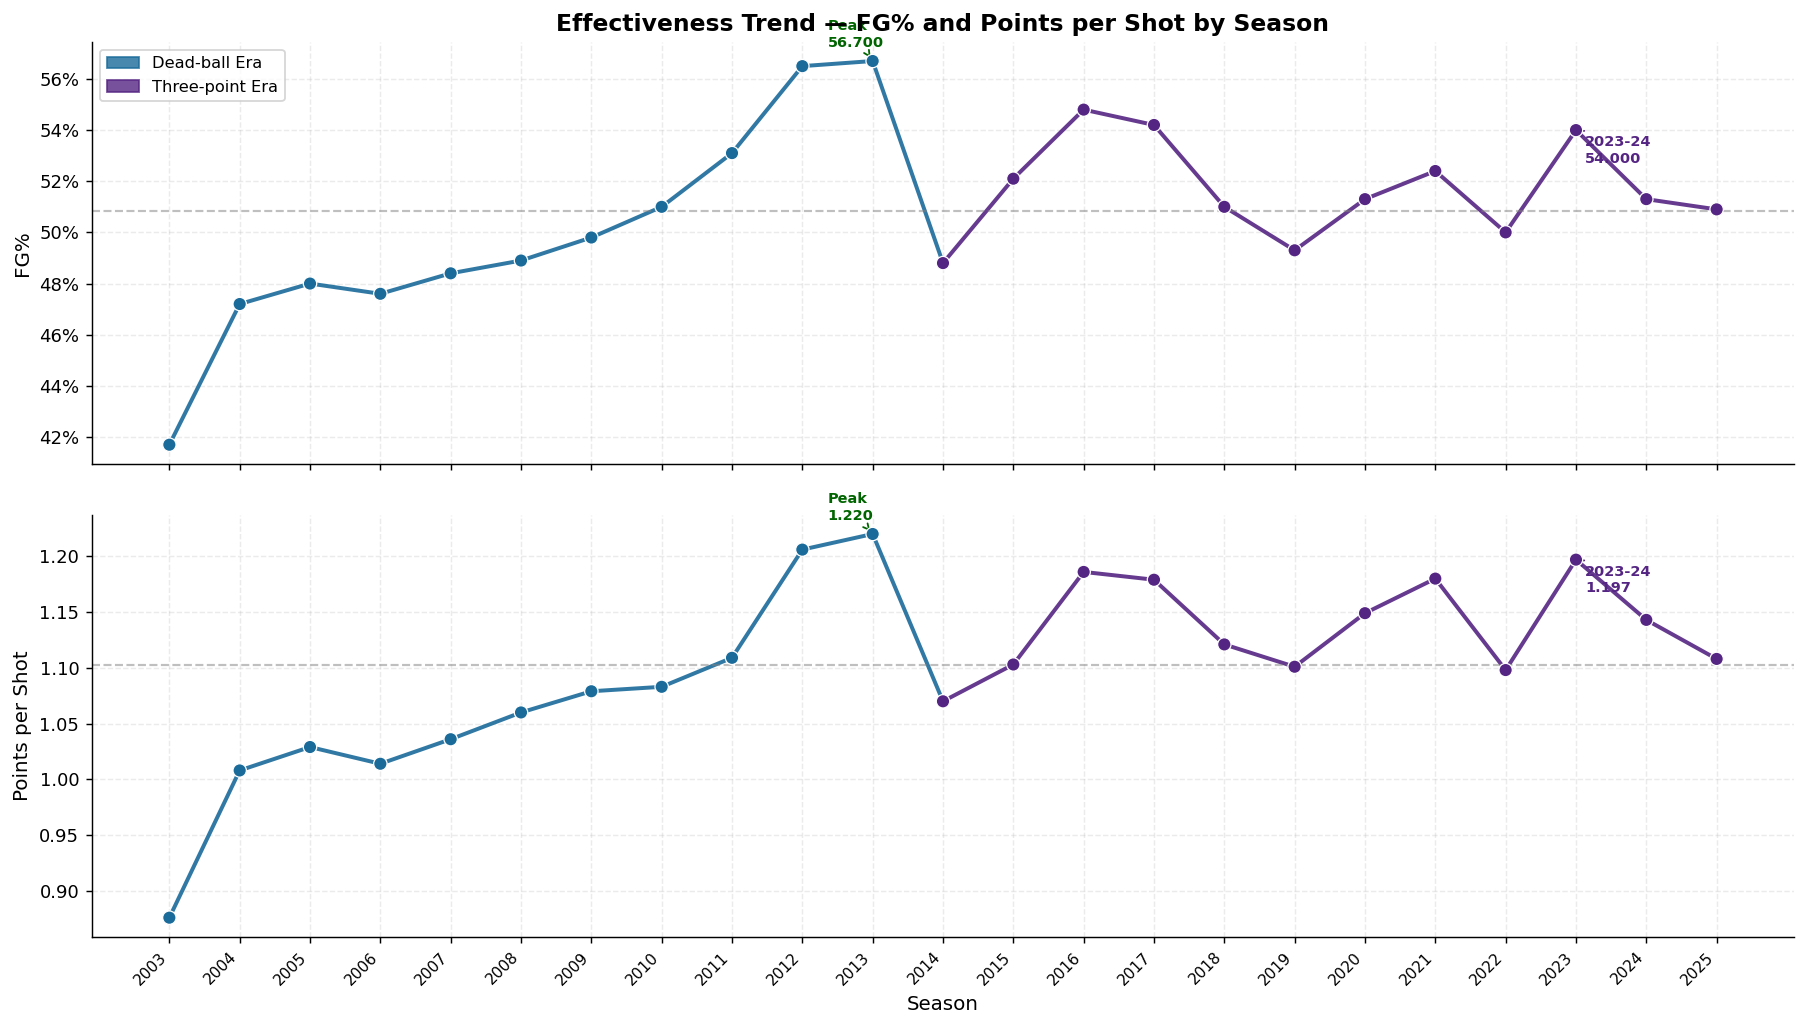

In [ ]:
# Effectiveness trend  -  all seasons, FG% and PPS side by side
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

x    = np.arange(len(bs_df))
clrs = [ERA_DEAD if e == 'Dead-ball Era' else ERA_THREE for e in bs_df['era']]

# FG% line
for i in range(len(x)-1):
    axes[0].plot(x[i:i+2], bs_df['fg_pct'].iloc[i:i+2],
                 color=clrs[i], lw=2.2, alpha=0.9)
axes[0].scatter(x, bs_df['fg_pct'], c=clrs, s=55, zorder=5,
                edgecolors='white', lw=0.7)
axes[0].axhline(bs_df['fg_pct'].mean(), color='grey', lw=1.2, ls='--', alpha=0.5)
axes[0].set_ylabel('FG%', fontsize=11)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))
axes[0].set_title('Effectiveness Trend  -  FG% and Points per Shot by Season',
                  fontsize=13, fontweight='bold')

# Points per shot line
for i in range(len(x)-1):
    axes[1].plot(x[i:i+2], bs_df['points_per_shot'].iloc[i:i+2],
                 color=clrs[i], lw=2.2, alpha=0.9)
axes[1].scatter(x, bs_df['points_per_shot'], c=clrs, s=55, zorder=5,
                edgecolors='white', lw=0.7)
axes[1].axhline(bs_df['points_per_shot'].mean(), color='grey', lw=1.2, ls='--', alpha=0.5)
axes[1].set_ylabel('Points per Shot', fontsize=11)

# annotate peak and 2023-24
for ax, col in [(axes[0], 'fg_pct'), (axes[1], 'points_per_shot')]:
    peak_i = bs_df[col].idxmax()
    lak24_i = bs_df[bs_df['season'] == '2023-24'].index[0]
    val_peak = bs_df[col].iloc[peak_i]
    val_lak  = bs_df[col].iloc[lak24_i]
    ax.annotate(f"Peak\n{val_peak:.3f}", xy=(peak_i, val_peak),
                xytext=(-25, 8), textcoords='offset points', fontsize=8,
                color='darkgreen', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='darkgreen', lw=1))
    ax.annotate(f"2023-24\n{val_lak:.3f}", xy=(lak24_i, val_lak),
                xytext=(5, -18), textcoords='offset points', fontsize=8,
                color=PURPLE, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=PURPLE, lw=1))

axes[1].set_xticks(x)
axes[1].set_xticklabels(bs_df['season'].str[:4], rotation=45, ha='right', fontsize=8.5)
axes[1].set_xlabel('Season', fontsize=11)

dead_p  = mpatches.Patch(color=ERA_DEAD,  alpha=0.8, label='Dead-ball Era')
three_p = mpatches.Patch(color=ERA_THREE, alpha=0.8, label='Three-point Era')
axes[0].legend(handles=[dead_p, three_p], fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

### 9.5 Multi-Dimension Rankings

The table below shows every season with all four rank columns. A season that appears in the top 5 across multiple dimensions is the truest claim to "best season overall."

2017-18 Cavs II is the only season in the top 5 for both scoring (#2) and effectiveness (#4). 2013-14 Heat leads effectiveness but ranks outside the top 10 for volume and scoring because the Miami system deliberately kept his usage lower. 2005-06 Cavs I dominates volume and scoring but ranks 20th in FG% - pure workload.


In [ ]:
rank_overview = bs_df[[
    'season','tenure','total_shots','fg_pct','points_per_shot','total_points',
    'rank_shots','rank_points','rank_fg','rank_pps'
]].copy()
rank_overview['combined_rank'] = (rank_overview['rank_shots'] +
                                   rank_overview['rank_points'] +
                                   rank_overview['rank_fg'] +
                                   rank_overview['rank_pps'])
rank_overview = rank_overview.sort_values('combined_rank')
rank_overview.index = range(1, len(rank_overview)+1)

display(rank_overview.style
    .background_gradient(subset=['rank_shots'],  cmap='Blues_r',   vmin=1, vmax=23)
    .background_gradient(subset=['rank_points'], cmap='Purples_r', vmin=1, vmax=23)
    .background_gradient(subset=['rank_fg'],     cmap='Greens_r',  vmin=1, vmax=23)
    .background_gradient(subset=['rank_pps'],    cmap='Oranges_r', vmin=1, vmax=23)
    .background_gradient(subset=['fg_pct'],      cmap='RdYlGn',    vmin=41, vmax=57)
    .format({
        'total_shots':    '{:,}',
        'fg_pct':         '{:.1f}%',
        'points_per_shot':'{:.3f}',
        'total_points':   '{:,}',
    })
    .set_caption('All Seasons Ranked  -  Lower combined rank = better overall season'))

,season,tenure,total_shots,fg_pct,points_per_shot,total_points,rank_shots,rank_points,rank_fg,rank_pps,combined_rank
1,2017-18,Cavs II,"1,580",54.2%,1.179,"1,863",6,2,4,6,18
2,2013-14,Heat,"1,353",56.7%,1.220,"1,650",13,7,1,1,22
3,2012-13,Heat,"1,354",56.5%,1.206,"1,633",12,9,2,2,25
4,2016-17,Cavs II,"1,357",54.8%,1.186,"1,610",11,10,3,4,28
5,2023-24,Lakers,"1,269",54.0%,1.197,"1,519",17,13,5,3,38
6,2005-06,Cavs I,"1,837",48.0%,1.029,"1,891",1,1,20,20,42
7,2015-16,Cavs II,"1,415",52.1%,1.103,"1,561",10,12,8,12,42
8,2009-10,Cavs I,"1,556",49.8%,1.079,"1,679",7,6,15,16,44
9,2008-09,Cavs I,"1,613",48.9%,1.060,"1,710",5,4,17,18,44
10,2021-22,Lakers,"1,221",52.4%,1.180,"1,441",18,15,7,5,45


## 10. Summary

Five findings from 31,182 shots across 21 seasons:

1. Era adaptation works. Three-point rate went from 19.8% to 28.8% between eras. Overall FG% went from 49.6% to 51.8%. Points per shot from 1.060 to 1.138. Every efficiency metric improved as he adopted a supposedly less efficient shot profile.

2. Miami was the peak. 54.3% FG across four seasons, including 56.5% and 56.7% back-to-back. No high-usage player in the modern era has matched that sustained efficiency.

3. The clutch gap is real but overstated. He shoots 3.8pp worse in clutch situations. Shot selection (more threes) explains part of it. On actual game-winning final possessions, 38.6% on 497 attempts is defensible.

4. The Clippers have figured him out the best. 47.4% FG on 998 shots - the worst large-sample matchup of his career. Detroit second (47.6% on 1,250), tracing back to 2005-2008 "LeBron Rules" playoff defenses.

5. 2023-24 at 39 is quietly historic. 54.0% FG and 1.197 points per shot - third-highest PPS of his entire career, behind only the two Miami peaks. He got there through a completely different shot profile from those Miami years.

The overarching story is adaptation. He didn't peak in 2013 and hang on. He rebuilt a different kind of efficiency that has held through his late 30s, trading the long mid-range game for three-point volume while his paint finishing improved at the same time.


In [ ]:
# Close the connection when done
conn.close()
print("Done. Connection closed.")

Done. Connection closed.
